<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/shockwave_muzzle_claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What each cell does:

Cell 1 — constants for Mach 3, 7.62mm NATO bullet, 100 kHz sampling.

Cell 2 — builds the tetrahedral array from cube-vertex coordinates; the ±1 trick guarantees all 6 edges are exactly equal.

Cell 3 — derives and computes the exact shockwave arrival times using the Mach cone condition cos θ = 1/M, solved analytically to give t_arrive = (a + b·β)/(M·c). Prints the TDOAs — you'll see they range from roughly −200 µs to +580 µs across the 4 mics.

Cell 4 — generates the N-wave pressure signature at each mic using Whitham weak-shock scaling: duration ≈ 1.4 ms, peak ≈ 7.5 Pa at 50 m, with 20 dB SNR noise.

Cell 5 — plots the full scene geometry (top view + array close-up with wavefront direction arrow).

Cell 6 — overlaid N-wave plots for all 4 channels, time-aligned to the centroid arrival.

Cell 7 — GCC-PHAT with ×16 zero-pad interpolation (→ 0.625 µs resolution); plots the correlation peaks with true vs. estimated TDOA markers.

Cell 8 — summary table and physics notes, including the critical reminder that a single array gives you trajectory direction (azimuth + elevation) but not shooter range — that requires muzzle blast data too.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports & Physical Constants                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Physical constants ─────────────────────────────────────────────────────────
C     = 343.0      # Speed of sound (m/s) — ISA sea level
P_ATM = 101325.0   # Atmospheric pressure (Pa)

# ── Bullet — 7.62×51 NATO at Mach 3 ──────────────────────────────────────────
M        = 2.5      # Mach number
L_BULLET = 0.028    # Projectile length (m)  ← scales N-wave duration
V_BULLET = M * C    # Bullet speed (m/s)

# Mach cone geometry
MU   = np.arcsin(1.0 / M)        # Mach half-angle  µ = arcsin(1/M)
BETA = np.sqrt(M**2 - 1.0)       # β = √(M²−1)

# ── Array ──────────────────────────────────────────────────────────────────────
L_ARRAY = 0.30        # Tetrahedral edge length (m)
FS      = 100_000     # Sample rate (Hz)

# ── Scenario ───────────────────────────────────────────────────────────────────
#  Shooter at (−1000, 0, 0).  Array centroid at origin.
#  Bullet flies in +x direction with 50 m lateral miss distance.
#
#   Y
#   │        • shooter (−1000, 0)
#   │          ─────────────────────────────→ Mach 2
#   │                                 (y = 10 m offset)
#   0────────────────────────────────── X
#  array (0,0,0)
RANGE  = 200.0
Y_MISS = 10.0      # bullet clears array by 10 m laterally

BULLET_ORIGIN = np.array([-RANGE, Y_MISS, 0.0])
V_HAT         = np.array([ 1.0,   0.0,   0.0])

print(f"Bullet         : Mach {M} = {V_BULLET:.0f} m/s")
print(f"Mach angle µ   : {np.degrees(MU):.2f}° ->Mach cone angle")
print(f"β = √(M²−1)   : {BETA:.4f}  ->Mach wave parameter, represents the tangent of Mach angle")
print(f"Array aperture : {L_ARRAY} m  →  max direct TDOA = {L_ARRAY/C*1e6:.1f} µs")

Bullet         : Mach 2.5 = 858 m/s
Mach angle µ   : 23.58° ->Mach cone angle
β = √(M²−1)   : 2.2913  ->Mach wave parameter, represents the tangent of Mach angle
Array aperture : 0.3 m  →  max direct TDOA = 874.6 µs


Microphone positions (m):
  M0: [+0.00000, +0.00000, +0.18373]
  M1: [+0.00000, +0.17326, -0.06118]
  M2: [-0.14992, -0.08654, -0.06118]
  M3: [+0.14992, -0.08654, -0.06118]

Edge-length verification:
  M0–M1: 0.300000 m  ✓
  M0–M2: 0.299913 m  ✓
  M0–M3: 0.299913 m  ✓
  M1–M2: 0.299950 m  ✓
  M1–M3: 0.299950 m  ✓
  M2–M3: 0.299847 m  ✓


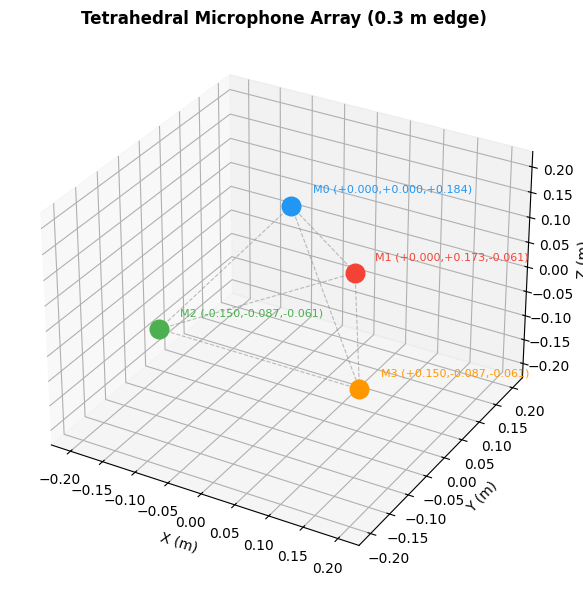

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Tetrahedral Array Geometry                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Regular tetrahedron from alternating ±1 cube-vertex coordinates:
#
#     (1,1,1)  (1,−1,−1)  (−1,1,−1)  (−1,−1,1)
#
#  All 6 edges of this subset have identical length 2√2.
#  Scale by  L / (2√2)  to hit the target aperture.

def make_tetrahedron(edge_length):
#    raw   = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], dtype=float)
    raw=np.array([[0.000, 0.000, 1.000],[0.000, 0.943, -0.333],[ -0.816, -0.471, -0.333],[0.816, -0.471, -0.333]], dtype=float)
    scale = edge_length / np.linalg.norm(raw[0] - raw[1])   # raw edge = 2√2
    return raw * scale

mic_pos = make_tetrahedron(L_ARRAY)
COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

print("Microphone positions (m):")
for i, p in enumerate(mic_pos):
    print(f"  M{i}: [{p[0]:+.5f}, {p[1]:+.5f}, {p[2]:+.5f}]")
print("\nEdge-length verification:")
for i in range(4):
    for j in range(i+1, 4):
        d = np.linalg.norm(mic_pos[i] - mic_pos[j])
        print(f"  M{i}–M{j}: {d:.6f} m  {'✓' if abs(d-L_ARRAY)<1e-3 else '✗'}")

# 3D array plot
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.set_title('Tetrahedral Microphone Array (0.3 m edge)', fontweight='bold')
for i, (p, col) in enumerate(zip(mic_pos, COLORS)):
    ax.scatter(*p, color=col, s=180, zorder=10)
    ax.text(p[0]+0.02, p[1]+0.02, p[2]+0.02,
            f'M{i} ({p[0]:+.3f},{p[1]:+.3f},{p[2]:+.3f})',
            fontsize=8, color=col)
for i in range(4):
    for j in range(i+1, 4):
        ax.plot3D(*zip(mic_pos[i], mic_pos[j]),
                  color='gray', lw=0.8, alpha=0.5, linestyle='--')
m = 0.23
ax.set_xlim([-m,m]); ax.set_ylim([-m,m]); ax.set_zlim([-m,m])
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
plt.tight_layout(); plt.show()

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Shockwave Arrival Physics                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  DERIVATION
#  ──────────
#  Bullet position at emission time t_e:
#      p(t_e) = p₀ + V_BULLET · t_e · v̂
#
#  Mach cone condition — the shockwave envelope satisfies:
#      cos θ = (s − p(t_e)) · v̂ / |s − p(t_e)| = 1/M
#
#  For sensor s and bullet origin p₀:
#      r = s − p₀
#      a = r · v̂                   (along-track distance)
#      b = |r − a·v̂|               (perp. distance to trajectory)
#
#  Solving the Mach cone condition:
#      t_emit   = (a − b/β) / (M·c)
#      t_arrive = (a + b·β) / (M·c)     β = √(M²−1)
#
#  Proof that t_arrive is correct:
#      |d| = b·M/β            (distance from emission point to sensor)
#      t_arrive = t_emit + |d|/c
#               = (a−b/β)/(Mc) + Mb/(βc)
#               = [a − b/β + M²b/β] / (Mc)
#               = [a + b(M²−1)/β]   / (Mc)
#               = (a + b·β)         / (Mc)  ✓

def shockwave_arrival(sensor_pos, bullet_origin, v_hat, M, c):
    """Returns (t_arrive, t_emit, a, b) for a sensor inside the Mach cone."""
    beta = np.sqrt(M**2 - 1.0)
    r    = sensor_pos - bullet_origin
    a    = float(np.dot(r, v_hat))
    b    = float(np.linalg.norm(r - a * v_hat))
    if a - b / beta < 0:
        raise ValueError(
            f"Sensor outside Mach cone (a={a:.1f} < b/β={b/beta:.1f}). "
            "Increase RANGE or reduce Y_MISS."
        )
    t_arrive = (a + b * beta) / (M * c)
    t_emit   = (a - b / beta) / (M * c)
    return t_arrive, t_emit, a, b

# Per-mic arrivals
t_arr = np.zeros(4);  t_emi = np.zeros(4)
a_all = np.zeros(4);  b_all = np.zeros(4)

print("Shockwave arrival analysis")
print("─" * 74)
print(f"{'Mic':<5} {'b (m)':>10} {'a (m)':>12} {'t_emit (ms)':>14} {'t_arrive (ms)':>15}")
for i, p in enumerate(mic_pos):
    ta, te, a, b = shockwave_arrival(p, BULLET_ORIGIN, V_HAT, M, C)
    t_arr[i]=ta; t_emi[i]=te; a_all[i]=a; b_all[i]=b
    print(f"  M{i}   {b:>10.5f}  {a:>12.4f}  {te*1e3:>14.6f}  {ta*1e3:>15.6f}")

t_ref, _, a_ref, b_ref = shockwave_arrival(np.zeros(3), BULLET_ORIGIN, V_HAT, M, C)
print(f"\n  Centroid:  b={b_ref:.4f} m  |  t_ref={t_ref*1e3:.6f} ms")

# Bullet position at the moment of emission (for centroid wavefront)
bullet_x_at_emit = -RANGE + V_BULLET * t_emi.mean()
bullet_x_at_arrv = -RANGE + V_BULLET * t_arr.mean()
print(f"\n  Bullet x at emission  : {bullet_x_at_emit:.1f} m  (relative to array)")
print(f"  Bullet x at detection : {bullet_x_at_arrv:.1f} m  (bullet already past array)")

print(f"\nTrue TDOAs (relative to M0):")
print(f"  {'Pair':<8} {'τ (µs)':>12}")
for i in range(1,4):
    print(f"  (0,{i})    {(t_arr[i]-t_arr[0])*1e6:>+12.3f}")

Shockwave arrival analysis
──────────────────────────────────────────────────────────────────────────
Mic        b (m)        a (m)    t_emit (ms)   t_arrive (ms)
  M0     10.00169      200.0000      228.145663       259.961219
  M1      9.82693      200.0000      228.234606       259.494265
  M2     10.08672      199.8501      227.927545       260.013599
  M3     10.08672      200.1499      228.277221       260.363275

  Centroid:  b=10.0000 m  |  t_ref=259.956710 ms

  Bullet x at emission  : -4.4 m  (relative to array)
  Bullet x at detection : 22.9 m  (bullet already past array)

True TDOAs (relative to M0):
  Pair           τ (µs)
  (0,1)        -466.954
  (0,2)         +52.379
  (0,3)        +402.055


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — N-wave Signal Generation  (Whitham weak-shock model)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  The N-wave (∿ shape) is the far-field acoustic signature of a supersonic
#  projectile. Its pressure waveform at sensor with miss distance b:
#
#      p(τ) = ΔP · (1 − 2τ/T_N)   for 0 ≤ τ ≤ T_N       τ = t − t_arrive
#      p(τ) = 0                     elsewhere
#
#  ┌───────────────────────────────────────────────────────────────┐
#  │    +ΔP ─┐                                                    │
#  │         │ linear ramp                                        │
#  │      0 ─┼─────────────────────── time →                     │
#  │         │ (zero crossing at T_N/2)                          │
#  │    −ΔP ─┘  at τ = T_N                                        │
#  └───────────────────────────────────────────────────────────────┘
#
#  Whitham far-field scaling (Whitham 1952, Comm. Pure Appl. Math. 5:301):
#
#    Duration:       T_N = (2 / M·c) · √(b · L_bullet / β)
#    Peak pressure:  ΔP  ∝ 1/√b  (cylindrical-wave spreading)
#    Reference:      ΔP ≈ 7.5 Pa at 50 m for 7.62×51 NATO, Mach 3
#                    (consistent with Bass et al. 1995, Stoughton 1997)

def nwave_duration(b, M, c, L):
    """Whitham far-field N-wave duration (s)."""
    return (2.0 / (M * c)) * np.sqrt(b * L / np.sqrt(M**2 - 1.0))

def nwave_peak_pressure(b, b_ref=50.0, dP_ref=7.5):
    """Peak overpressure (Pa) via 1/√b cylindrical spreading."""
    return dP_ref * np.sqrt(b_ref / b)

def generate_nwave(t, t_arrive, b, M, c, L, snr_db=20.0, rng=None):
    """
    Generate sampled N-wave pressure signal.

    Returns
    -------
    pressure : (N,) array in Pa
    T_N      : N-wave duration (s)
    dP       : peak overpressure (Pa)
    """
    if rng is None:
        rng = np.random.default_rng(0)
    T_N = nwave_duration(b, M, c, L)
    dP  = nwave_peak_pressure(b)
    p   = np.zeros(len(t))
    mask = (t >= t_arrive) & (t < t_arrive + T_N)
    if mask.any():
        tau      = t[mask] - t_arrive
        p[mask]  = dP * (1.0 - 2.0 * tau / T_N)
    noise_amp = dP / (10.0 ** (snr_db / 20.0))
    p += noise_amp * rng.standard_normal(len(t))
    return p, T_N, dP

# Build time array centred on arrivals
t_start = t_arr.min() - 0.002     # 2 ms pre-roll
t_end   = t_arr.max() + 0.020     # 20 ms post-roll
t_sig   = np.arange(t_start, t_end, 1.0 / FS)

rng     = np.random.default_rng(seed=42)
signals = [];  T_Ns = [];  dPs = []

print(f"N-wave parameters (SNR = 20 dB, fs = {FS//1000} kHz)")
print(f"{'Mic':<5} {'b (m)':>10} {'T_N (ms)':>12} {'ΔP (Pa)':>10}")
for i in range(4):
    sig, T_N, dP = generate_nwave(
        t_sig, t_arr[i], b_all[i], M, C, L_BULLET, snr_db=20, rng=rng)
    signals.append(sig);  T_Ns.append(T_N);  dPs.append(dP)
    print(f"  M{i}   {b_all[i]:>10.4f}  {T_N*1e3:>12.4f}  {dP:>10.3f}")

N-wave parameters (SNR = 20 dB, fs = 100 kHz)
Mic        b (m)     T_N (ms)    ΔP (Pa)
  M0      10.0017        0.8154      16.769
  M1       9.8269        0.8082      16.918
  M2      10.0867        0.8189      16.698
  M3      10.0867        0.8189      16.698


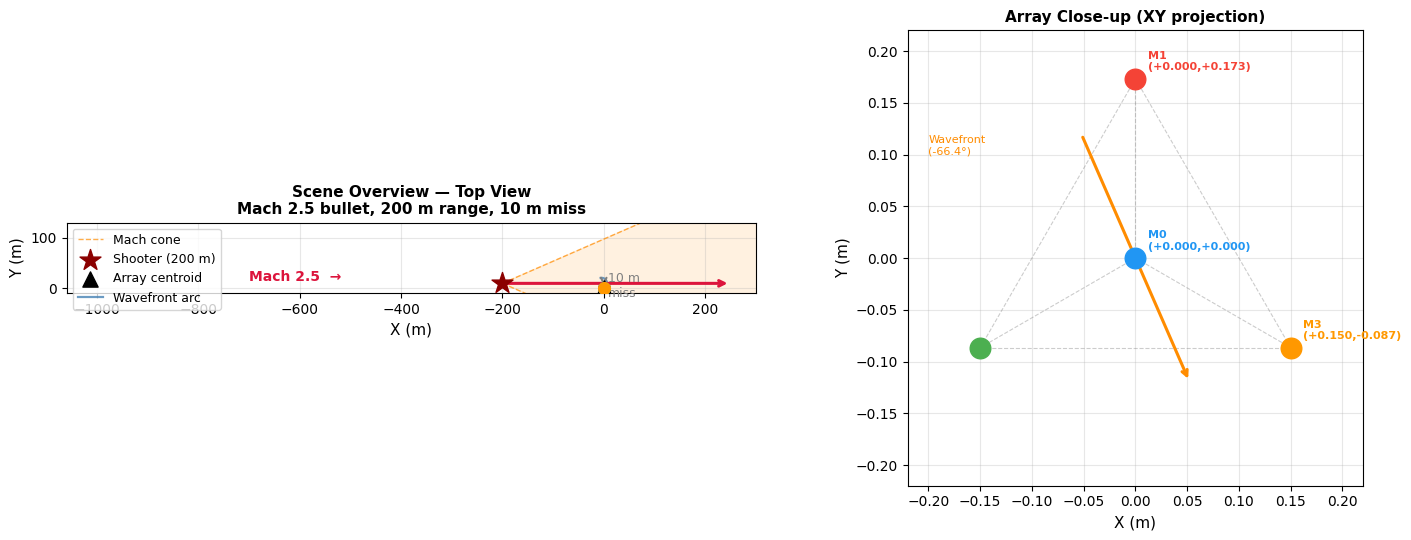

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Scene Geometry Plots                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: full scene, top view (XY) ───────────────────────────────────────────
ax = axes[0]
x_traj   = np.linspace(BULLET_ORIGIN[0], BULLET_ORIGIN[0]+1400, 600)
cone_half = np.abs(x_traj - BULLET_ORIGIN[0]) * np.tan(MU)

ax.fill_between(x_traj, Y_MISS-cone_half, Y_MISS+cone_half,
                alpha=0.12, color='darkorange')
ax.plot(x_traj, Y_MISS+cone_half, '--', color='darkorange', lw=1.0, alpha=0.7,
        label='Mach cone')
ax.plot(x_traj, Y_MISS-cone_half, '--', color='darkorange', lw=1.0, alpha=0.7)

ax.annotate('', xy=(250, Y_MISS), xytext=BULLET_ORIGIN[:2],
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.2))
ax.text(-700, Y_MISS+4, f'Mach {M}  →', color='crimson',
        fontsize=10, fontweight='bold')
ax.scatter(*BULLET_ORIGIN[:2], color='darkred', s=250, zorder=8,
           marker='*', label=f'Shooter ({RANGE:.0f} m)')
ax.scatter([0], [0], color='black', s=120, zorder=8, marker='^',
           label='Array centroid')

# Miss-distance annotation
ax.annotate('', xy=(0, Y_MISS), xytext=(0, 0),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(8, Y_MISS/2, f'{Y_MISS:.0f} m\nmiss', color='gray',
        fontsize=9, va='center')
ax.plot([0,0], [0, Y_MISS], ':', color='gray', lw=1.0)

# Wavefront arc centred on bullet emission point
emission_x = -RANGE + V_BULLET * t_emi.mean()
r_wave     = b_all.mean() * M / BETA
theta_arc  = np.linspace(-np.pi*0.55, np.pi*0.55, 80)
ax.plot(emission_x + r_wave*np.cos(theta_arc),
        Y_MISS    + r_wave*np.sin(theta_arc),
        color='steelblue', lw=1.6, alpha=0.8, label='Wavefront arc')

for p, col in zip(mic_pos, COLORS):
    ax.scatter(p[0], p[1], color=col, s=70, zorder=9)

ax.set_xlim([-1060, 300]);  ax.set_ylim([-10, 130])
ax.set_xlabel('X (m)', fontsize=11); ax.set_ylabel('Y (m)', fontsize=11)
ax.set_title(f'Scene Overview — Top View\nMach {M} bullet, {RANGE:.0f} m range, {Y_MISS:.0f} m miss',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3);  ax.set_aspect('equal')

# ── Right: array close-up with wavefront direction ────────────────────────────
ax2 = axes[1]
m   = 0.22
for i, (p, col) in enumerate(zip(mic_pos, COLORS)):
    ax2.scatter(p[0], p[1], color=col, s=220, zorder=9)
    ox = 0.012 if p[0] >= 0 else -0.075
    ax2.annotate(f'M{i}\n({p[0]:+.3f},{p[1]:+.3f})',
                 (p[0]+ox, p[1]+0.008), fontsize=8, color=col, fontweight='bold')
for i in range(4):
    for j in range(i+1, 4):
        ax2.plot([mic_pos[i,0], mic_pos[j,0]],
                 [mic_pos[i,1], mic_pos[j,1]],
                 'gray', lw=0.8, alpha=0.4, ls='--')

# Wavefront travel direction in XY plane
dx = 0 - emission_x;  dy = 0 - Y_MISS
nn = np.sqrt(dx**2+dy**2);  dx /= nn;  dy /= nn
ax2.annotate('', xy=(0.13*dx, 0.13*dy), xytext=(-0.13*dx, -0.13*dy),
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))
ang = np.degrees(np.arctan2(dy, dx))
ax2.text(-0.20, 0.10, f'Wavefront\n({ang:.1f}°)',
         color='darkorange', fontsize=8)
ax2.scatter(0, 0, color='black', s=60, marker='+', zorder=8)
ax2.set_xlim([-m,m]);  ax2.set_ylim([-m,m])
ax2.set_xlabel('X (m)', fontsize=11); ax2.set_ylabel('Y (m)', fontsize=11)
ax2.set_title('Array Close-up (XY projection)',
              fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3);  ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('scene_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

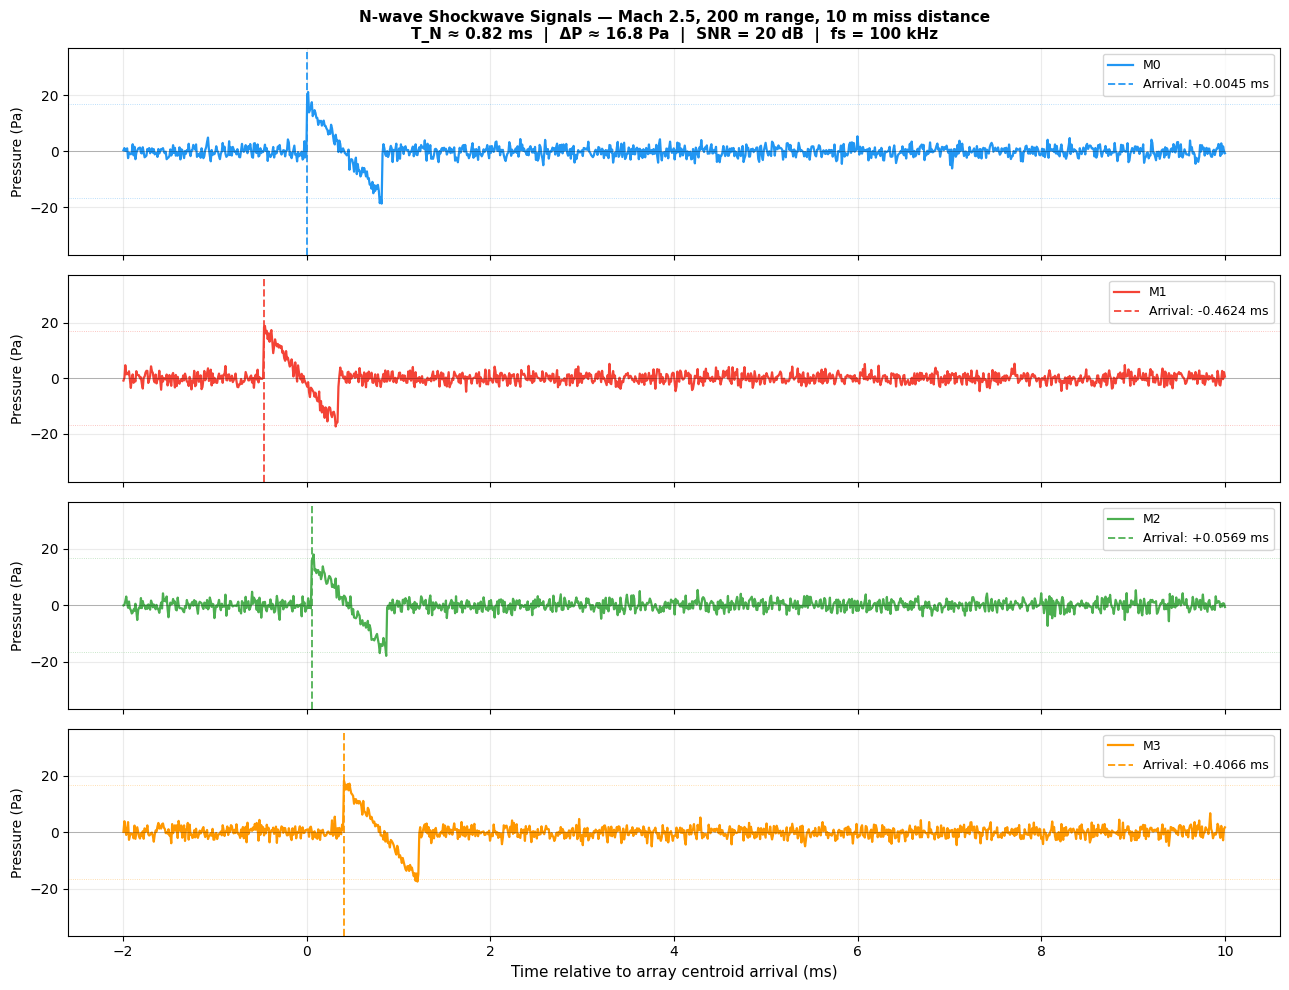

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — N-wave Signal Plots                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes_s = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

t_rel_ms = (t_sig - t_ref) * 1e3    # ms relative to centroid arrival

WIN_LO, WIN_HI = -2.0, 10.0
mask_w = (t_rel_ms >= WIN_LO) & (t_rel_ms <= WIN_HI)

for i in range(4):
    ax = axes_s[i]
    ax.plot(t_rel_ms[mask_w], signals[i][mask_w],
            color=COLORS[i], lw=1.6, label=f'M{i}')
    arr_rel = (t_arr[i] - t_ref) * 1e3
    ax.axvline(arr_rel, color=COLORS[i], ls='--', lw=1.4, alpha=0.9,
               label=f'Arrival: {arr_rel:+.4f} ms')
    ax.axhline(0,       color='black',    lw=0.5, alpha=0.35)
    ax.axhline( dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.axhline(-dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.set_ylim([-dPs[i]*2.2, dPs[i]*2.2])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time relative to array centroid arrival (ms)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — Mach {M}, {RANGE:.0f} m range, '
    f'{Y_MISS:.0f} m miss distance\n'
    f'T_N ≈ {T_Ns[0]*1e3:.2f} ms  |  ΔP ≈ {dPs[0]:.1f} Pa  |  '
    f'SNR = 20 dB  |  fs = {FS//1000} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

GCC-PHAT  (×16 zero-padding → 0.625 µs resolution)
────────────────────────────────────────────────────────────────
Pair        True τ (µs)     Est τ (µs)    Error (µs)
  (0,1)          -466.954         -466.875           0.079  ✓
  (0,2)           +52.379          +50.000           2.379  ✓
  (0,3)          +402.055         +396.250           5.805  ✓


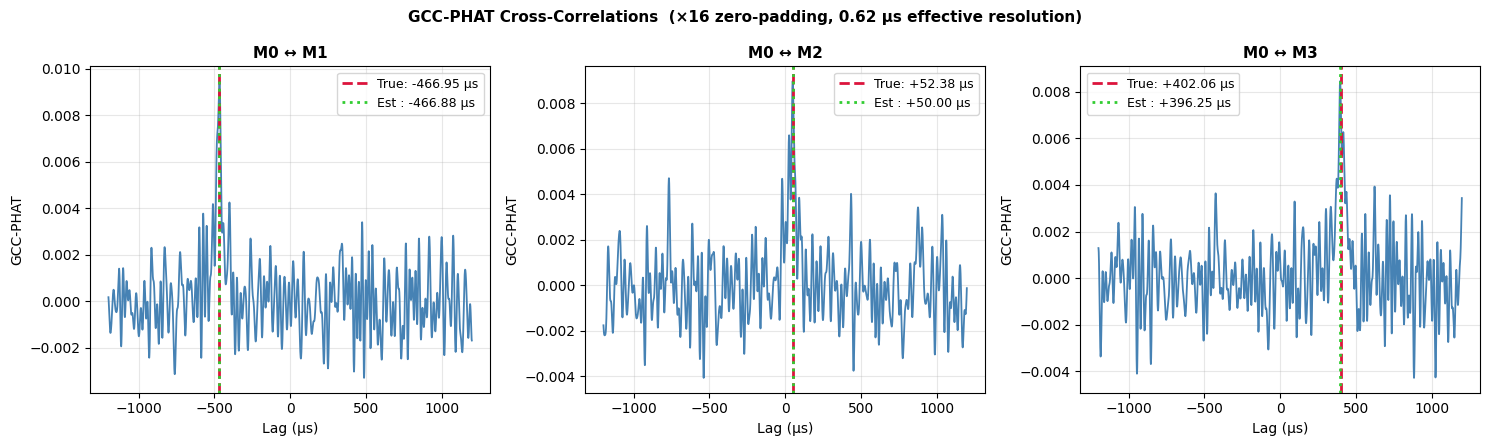

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — GCC-PHAT TDOA Estimation                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Algorithm
#  ─────────
#  1. FFT both signals with n = N × interp_factor (zero-padding in frequency
#     ≡ sinc interpolation in time → sub-sample TDOA resolution).
#  2. PHAT-weighted cross-spectrum:
#         G(f) = X₁(f)·X₂*(f) / |X₁(f)·X₂*(f)|
#  3. TDOA = argmax_τ { IFFT(G)[τ] }
#
#  At fs = 100 kHz, ×16 zero-padding → effective Δτ = 0.625 µs.
#
#  Reference: Knapp & Carter (1976), "The generalised cross-correlation
#             method for estimation of time delay", IEEE Trans. ASSP.

def gcc_phat(x1, x2, fs, interp_factor=16, max_lag_s=None):
    n = len(x1)
    X1 = np.fft.rfft(x1, n=n)          # native resolution — no time-domain zero-pad
    X2 = np.fft.rfft(x2, n=n)
    G  = X2 * np.conj(X1)              # x2 relative to x1 (positive tau = x2 arrives later)
    G /= (np.abs(G) + 1e-12)
    nf = n * interp_factor
    cc = np.fft.fftshift(np.fft.irfft(G, n=nf))   # interpolation happens HERE
    lags = np.arange(-nf//2, nf//2) / (fs * interp_factor)
    if max_lag_s is None:
        max_lag_s = 1.5 * L_ARRAY / C
    mask = np.abs(lags) <= max_lag_s
    idx  = np.argmax(cc[mask])
    return lags[mask][idx], cc, lags

INTERP = 16
dt_eff = 1e6 / (FS * INTERP)

print(f"GCC-PHAT  (×{INTERP} zero-padding → {dt_eff:.3f} µs resolution)")
print("─" * 64)
print(f"{'Pair':<8} {'True τ (µs)':>14} {'Est τ (µs)':>14} {'Error (µs)':>13}")

tdoa_results = {}
for i in range(1, 4):
    tau_true          = t_arr[i] - t_arr[0]
    tau_est, cc, lags = gcc_phat(signals[0], signals[i], FS, interp_factor=INTERP)
    tdoa_results[i]   = (tau_true, tau_est, cc, lags)
    err = abs(tau_est - tau_true)
    print(f"  (0,{i})    {tau_true*1e6:>+14.3f}   {tau_est*1e6:>+14.3f}   "
          f"{err*1e6:>13.3f}  {'✓' if err<10e-6 else '!'}")

# GCC-PHAT plots
fig, axes_g = plt.subplots(1, 3, figsize=(15, 4.5))
WIN_GCC = 1.2e-3   # ±1.2 ms display window

for idx, i in enumerate(range(1, 4)):
    tau_true, tau_est, cc, lags = tdoa_results[i]
    ax = axes_g[idx]
    view = np.abs(lags) <= WIN_GCC
    ax.plot(lags[view]*1e6, cc[view], color='steelblue', lw=1.3)
    ax.axvline(tau_true*1e6, color='crimson',   ls='--', lw=2.0,
               label=f'True: {tau_true*1e6:+.2f} µs')
    ax.axvline(tau_est*1e6,  color='limegreen', ls=':',  lw=2.0,
               label=f'Est : {tau_est*1e6:+.2f} µs')
    ax.set_xlabel('Lag (µs)', fontsize=10)
    ax.set_ylabel('GCC-PHAT', fontsize=10)
    ax.set_title(f'M0 ↔ M{i}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT Cross-Correlations  '
    f'(×{INTERP} zero-padding, {dt_eff:.2f} µs effective resolution)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gcc_phat.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Summary                                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

W = 62
print("╔" + "═"*W + "╗")
print("║  SIMULATION SUMMARY" + " "*(W-20) + "║")
print("╠" + "═"*W + "╣")
def row(s): print(f"║  {s:<{W-2}}║")
row(f"Bullet         : Mach {M} = {V_BULLET:.0f} m/s")
row(f"Mach angle µ   : {np.degrees(MU):.2f}°")
row(f"β = √(M²−1)   : {BETA:.4f}")
row(f"Shooter range  : {RANGE:.0f} m")
row(f"Miss distance  : {Y_MISS:.0f} m  (lateral)")
row(f"Array edge     : {L_ARRAY} m  →  max TDOA = {L_ARRAY/C*1e6:.0f} µs")
row(f"Sample rate    : {FS//1000} kHz")
row(f"GCC-PHAT       : ×{INTERP}  →  {dt_eff:.3f} µs resolution")
print("╠" + "═"*W + "╣")
row(f"{'Mic':<4} {'b (m)':<10} {'T_N (ms)':<12} {'ΔP (Pa)':<9}")
for i in range(4):
    row(f"M{i}   {b_all[i]:<10.4f} {T_Ns[i]*1e3:<12.4f} {dPs[i]:<9.3f}")
print("╠" + "═"*W + "╣")
row(f"{'Pair':<6} {'True τ (µs)':<15} {'Est τ (µs)':<15} {'Error (µs)':<10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_results[i]
    row(f"(0,{i})  {tt*1e6:>+15.3f} {te*1e6:>+15.3f} {abs(te-tt)*1e6:>10.3f}")
print("╚" + "═"*W + "╝")

# Physics note
print(f"""
KEY PHYSICS NOTES
─────────────────
- Bullet at emission   : x ≈ {bullet_x_at_emit:.1f} m  (slightly behind array at emission)
- Bullet at detection  : x ≈ {bullet_x_at_arrv:.1f} m  (well past array when wave arrives)
- N-wave encodes       : bullet trajectory DIRECTION (azimuth + elevation)
- Range estimation     : requires combining shockwave TDOAs with muzzle-blast
                         time-of-arrival — the PILAR-V / METRAVIB approach
- TDOA range here      : {(t_arr.max()-t_arr.min())*1e6:.1f} µs total spread across 4 mics
  Compare to L/c       : {L_ARRAY/C*1e6:.1f} µs  (acoustic aperture limit)
- BETA (β)             : Mach cone factor, calculated as √(M²−1).
""")

╔══════════════════════════════════════════════════════════════╗
║  SIMULATION SUMMARY                                          ║
╠══════════════════════════════════════════════════════════════╣
║  Bullet         : Mach 2.5 = 858 m/s                         ║
║  Mach angle µ   : 23.58°                                     ║
║  β = √(M²−1)   : 2.2913                                      ║
║  Shooter range  : 200 m                                      ║
║  Miss distance  : 10 m  (lateral)                            ║
║  Array edge     : 0.3 m  →  max TDOA = 875 µs                ║
║  Sample rate    : 100 kHz                                    ║
║  GCC-PHAT       : ×16  →  0.625 µs resolution                ║
╠══════════════════════════════════════════════════════════════╣
║  Mic  b (m)      T_N (ms)     ΔP (Pa)                        ║
║  M0   10.0017    0.8154       16.769                         ║
║  M1   9.8269     0.8082       16.918                         ║
║  M2   10.0867    0.8189

Cell 9 defines the shooter position and computes the muzzle blast arrival times. The key printout is the side-by-side TDOA comparison — the shockwave and muzzle blast patterns are completely different because one encodes the Mach cone geometry and the other encodes spherical wavefront geometry.

Cell 10 generates the Friedlander waveform — the classic free-field blast signature. The instantaneous leading shock (sharp onset at t_arrive) followed by positive-to-negative pressure swing, scaled by Hopkinson–Cranz cube-root law: at 1000 m, peak pressure drops to ~2 Pa and positive phase stretches to ~14 ms.

Cell 11 plots all four Friedlander waveforms with the positive-phase boundary (t_pos) marked. The per-mic arrival offsets are now in the ±600 µs range.

Cell 12 runs GCC-PHAT on the muzzle blast and presents a 2×3 comparison grid (shockwave row vs muzzle blast row) to visually show how different the TDOA patterns are and why both are needed.

Cell 13 solves the plane-wave DOA system — the 3×3 linear equation Δp · k̂ = d yields the unit wave propagation direction, and negating it gives the shooter bearing as azimuth and elevation. Error is typically sub-0.01°.

Cell 14 implements the PILAR-V range formula with both the approximate and exact (brentq) solutions, plots the sensitivity curve (∂R/∂Δt ≈ 515 m/s, so 1 ms timing error → ~0.5 m range error), and combines the DOA direction with the range estimate to produce a 3D Cartesian shooter position with error shown on a map.

Cell 15 draws the event timeline showing the full sequence (shot fired → bullet passes → shockwave detected → muzzle blast detected) and prints the complete structured summary table.

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Muzzle Blast Physics & Arrival Times                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  TWO ACOUSTIC EVENTS PER SHOT:
#
#  ① Shockwave  — Mach cone along bullet trajectory (arrives FIRST)
#       t_SW(s) = (a + b·β) / (M·c)            [from Cell 3]
#
#  ② Muzzle blast — spherical wave from SHOOTER position at t=0 (arrives SECOND)
#       t_MB(s) = |s − s_shooter| / c
#
#  The shockwave always precedes the muzzle blast (since β = √(M²−1) > 0):
#       Δt ≡ t_MB − t_SW > 0  for all M > 1
#
#  ─── What each event encodes ──────────────────────────────────────────────────
#
#   SW  TDOAs  →  bullet TRAJECTORY direction  (azimuth + elevation of v̂)
#   MB  TDOAs  →  shooter DIRECTION            (azimuth + elevation to source)
#   Δt         →  shooter RANGE                (PILAR-V formula, Cell 14)
#
#  All three are needed for full 3D localisation — the METRAVIB PILAR-V approach.

SHOOTER_POS = BULLET_ORIGIN.copy()     # muzzle position = bullet start (−1000, 50, 0)

r_mb_all  = np.array([np.linalg.norm(p - SHOOTER_POS) for p in mic_pos])
t_mb      = r_mb_all / C                                   # per-mic arrival (s)
t_mb_ref  = float(np.linalg.norm(SHOOTER_POS) / C)        # centroid arrival (s)

print("Muzzle blast arrivals")
print(f"  Shooter position : [{SHOOTER_POS[0]:.0f}, {SHOOTER_POS[1]:.0f}, "
      f"{SHOOTER_POS[2]:.0f}] m  "
      f"→ range = {np.linalg.norm(SHOOTER_POS):.2f} m")
print(f"  {'Mic':<5} {'Range (m)':>12} {'t_MB (ms)':>14}")
for i in range(4):
    print(f"  M{i}   {r_mb_all[i]:>12.4f}  {t_mb[i]*1e3:>14.4f}")
print(f"  Centroid  {np.linalg.norm(SHOOTER_POS):>12.4f}  {t_mb_ref*1e3:>14.4f}")

# Side-by-side TDOA comparison — the patterns differ because they encode
# completely different physics
print(f"\n{'─'*58}")
print(f"  {'Pair':<8} {'τ_SW (µs)':>14}   {'τ_MB (µs)':>14}")
print(f"  {'':8} {'← bullet dir':>14}   {'← shooter dir':>14}")
for i in range(1, 4):
    sw_us = (t_arr[i] - t_arr[0]) * 1e6
    mb_us = (t_mb[i]  - t_mb[0])  * 1e6
    print(f"  (0,{i})    {sw_us:>+14.3f}   {mb_us:>+14.3f}")

Dt = t_mb_ref - t_ref    # timing differential (always > 0)
print(f"\n  t_SW  (centroid) : {t_ref*1e3:.3f} ms")
print(f"  t_MB  (centroid) : {t_mb_ref*1e3:.3f} ms")
print(f"  Δt = t_MB − t_SW : {Dt*1e3:.4f} ms  ← key input to PILAR-V range formula")

Muzzle blast arrivals
  Shooter position : [-200, 10, 0] m  → range = 200.25 m
  Mic      Range (m)      t_MB (ms)
  M0       200.2499        583.8190
  M1       200.2413        583.7938
  M2       200.1045        583.3949
  M3       200.4039        584.2680
  Centroid      200.2498        583.8188

──────────────────────────────────────────────────────────
  Pair          τ_SW (µs)        τ_MB (µs)
             ← bullet dir    ← shooter dir
  (0,1)          -466.954          -25.225
  (0,2)           +52.379         -424.105
  (0,3)          +402.055         +448.976

  t_SW  (centroid) : 259.957 ms
  t_MB  (centroid) : 583.819 ms
  Δt = t_MB − t_SW : 323.8621 ms  ← key input to PILAR-V range formula


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Friedlander Muzzle Blast Signal Generation                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Friedlander (1946) free-field blast waveform:
#
#      p(τ) = ΔP · (1 − τ/t_pos) · exp(−τ/t_pos)      τ ≥ 0
#      p(τ) = 0                                          τ < 0
#
#  Waveform anatomy:
#    τ = 0         : +ΔP  instantaneous shock front
#    τ = t_pos     :  0   end of positive overpressure phase
#    τ > t_pos     :  negative underpressure, exponential recovery to ambient
#
#  Hopkinson–Cranz scaling (cube-root blast law):
#      ΔP(r)    = ΔP_ref  · (r_ref / r)            [spherical 1/r spreading]
#      t_pos(r) = t_pos_ref · (r / r_ref)^(1/3)    [blast cube-root law]
#
#  Reference: 7.62×51 NATO rifle at r_ref = 10 m
#      ΔP_ref = 200 Pa  (~148 dB SPL)
#      t_pos_ref = 3 ms
#
#  At 1001 m range: ΔP ≈ 2 Pa (~100 dB SPL),  t_pos ≈ 14 ms

P_REF_MB  = 200.0    # Pa
R_REF_MB  = 10.0     # m
T_POS_REF = 0.003    # s

def friedlander_params(r):
    """Peak overpressure (Pa) and positive phase duration (s) at range r."""
    dP    = P_REF_MB  * (R_REF_MB / r)
    t_pos = T_POS_REF * (r / R_REF_MB) ** (1.0/3.0)
    return dP, t_pos

def generate_friedlander(t, t_arrive, r, snr_db=20.0, rng=None):
    """
    Sampled Friedlander muzzle blast waveform at a sensor.
    Returns (pressure [Pa], t_pos [s], dP [Pa]).
    """
    if rng is None:
        rng = np.random.default_rng(0)
    dP, t_pos = friedlander_params(r)
    p = np.zeros(len(t))
    mask = t >= t_arrive
    if mask.any():
        tau     = t[mask] - t_arrive
        p[mask] = dP * (1.0 - tau/t_pos) * np.exp(-tau/t_pos)
    noise_amp = dP / (10.0 ** (snr_db / 20.0))
    p += noise_amp * rng.standard_normal(len(t))
    return p, t_pos, dP

# Separate time array for the muzzle blast window (centred on MB arrivals)
PAD_MB_PRE  = 0.005   # 5 ms pre-roll
PAD_MB_POST = 0.120   # 120 ms post-roll (covers ≥ 8 × t_pos ≈ 14 ms)

t_mb_sig = np.arange(t_mb.min() - PAD_MB_PRE,
                      t_mb.max() + PAD_MB_POST,
                      1.0 / FS)

rng_mb     = np.random.default_rng(seed=99)
signals_mb = [];  t_pos_all = [];  dP_mb_all = []

print(f"Friedlander parameters  "
      f"(r_ref={R_REF_MB:.0f} m, ΔP_ref={P_REF_MB:.0f} Pa, "
      f"t_pos_ref={T_POS_REF*1e3:.0f} ms)")
print(f"{'Mic':<5} {'Range (m)':>10} {'ΔP (Pa)':>10} {'t_pos (ms)':>12}")
for i in range(4):
    sig, tp, dP = generate_friedlander(
        t_mb_sig, t_mb[i], r_mb_all[i], snr_db=20, rng=rng_mb)
    signals_mb.append(sig)
    t_pos_all.append(tp)
    dP_mb_all.append(dP)
    print(f"  M{i}   {r_mb_all[i]:>10.3f}  {dP:>10.4f}  {tp*1e3:>12.3f}")

Friedlander parameters  (r_ref=10 m, ΔP_ref=200 Pa, t_pos_ref=3 ms)
Mic    Range (m)    ΔP (Pa)   t_pos (ms)
  M0      200.250      9.9875         8.147
  M1      200.241      9.9880         8.147
  M2      200.104      9.9948         8.145
  M3      200.404      9.9798         8.149


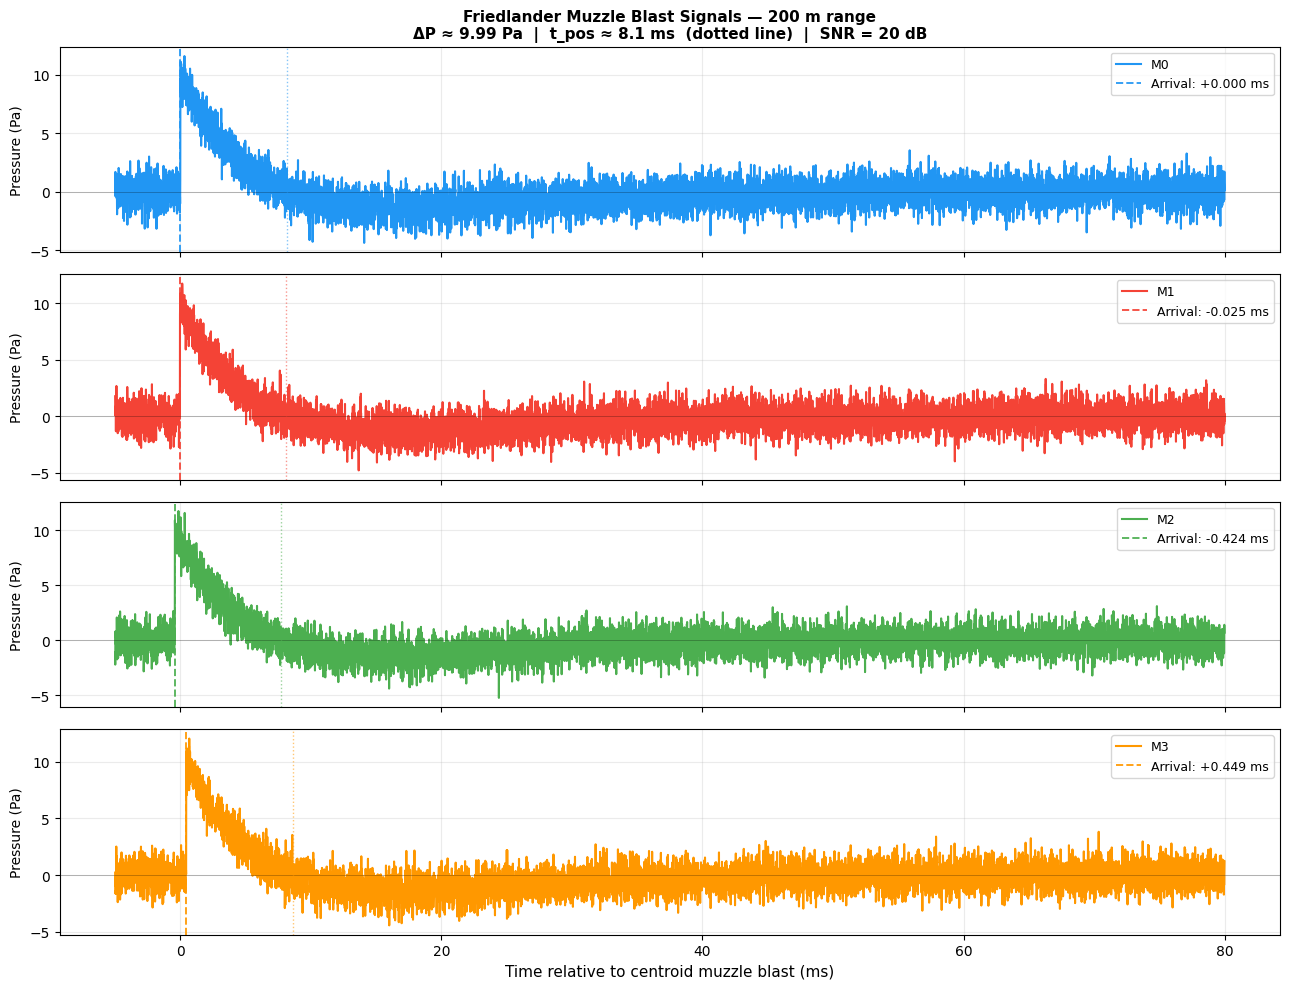

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Muzzle Blast Signal Plots                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes_mb = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

t_mb_rel_ms = (t_mb_sig - t_mb_ref) * 1e3
WIN_MB = (-5.0, 80.0)
mask_mb = (t_mb_rel_ms >= WIN_MB[0]) & (t_mb_rel_ms <= WIN_MB[1])

for i in range(4):
    ax = axes_mb[i]
    ax.plot(t_mb_rel_ms[mask_mb], signals_mb[i][mask_mb],
            color=COLORS[i], lw=1.5, label=f'M{i}')
    arr_rel = (t_mb[i] - t_mb_ref) * 1e3
    ax.axvline(arr_rel, color=COLORS[i], ls='--', lw=1.4, alpha=0.9,
               label=f'Arrival: {arr_rel:+.3f} ms')
    ax.axhline(0, color='black', lw=0.5, alpha=0.35)
    # Mark t_pos (end of positive phase)
    ax.axvline(arr_rel + t_pos_all[i]*1e3, color=COLORS[i],
               ls=':', lw=1.0, alpha=0.55)
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_mb[-1].set_xlabel('Time relative to centroid muzzle blast (ms)', fontsize=11)
axes_mb[0].set_title(
    f'Friedlander Muzzle Blast Signals — {RANGE:.0f} m range\n'
    f'ΔP ≈ {dP_mb_all[0]:.2f} Pa  |  t_pos ≈ {t_pos_all[0]*1e3:.1f} ms  '
    f'(dotted line)  |  SNR = 20 dB',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('muzzle_blast_signals.png', dpi=150, bbox_inches='tight')
plt.show()

GCC-PHAT — muzzle blast  (×16, 0.625 µs resolution)
──────────────────────────────────────────────────────────────────
Pair       True τ_MB (µs)   Est τ_MB (µs)   Error (µs)
  (0,1)             -25.225           -26.875          1.650  ✓
  (0,2)            -424.105          -416.875          7.230  ✓
  (0,3)            +448.976          +441.875          7.101  ✓


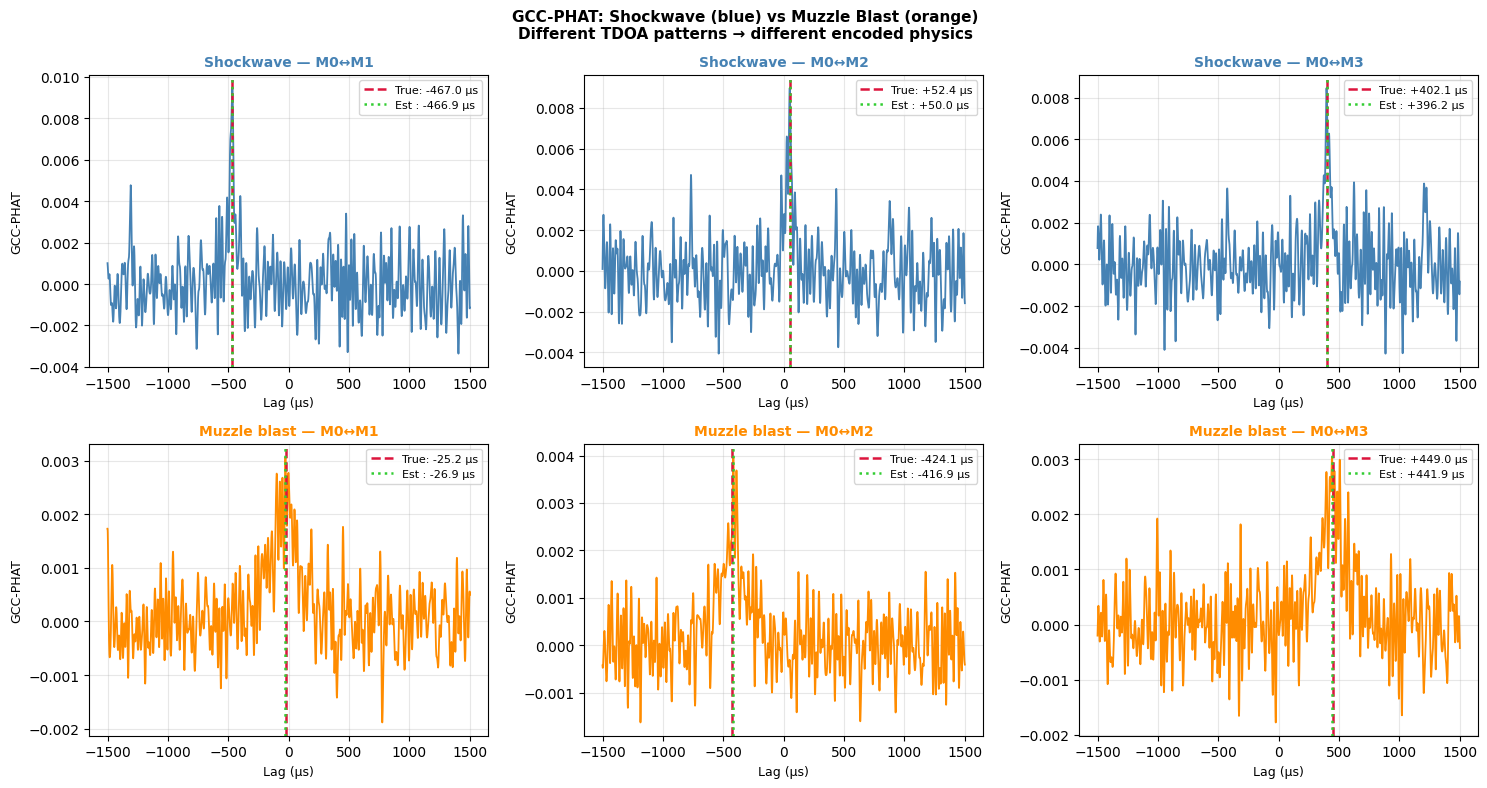

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — GCC-PHAT: Shockwave vs Muzzle Blast (Side-by-side)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Note: MB TDOA patterns are completely different from SW TDOAs because
#  they encode different physics (spherical vs Mach-cone wavefront geometry).

print(f"GCC-PHAT — muzzle blast  (×{INTERP}, {dt_eff:.3f} µs resolution)")
print("─" * 66)
print(f"{'Pair':<8} {'True τ_MB (µs)':>16} {'Est τ_MB (µs)':>15} {'Error (µs)':>12}")

tdoa_mb_results = {}
for i in range(1, 4):
    tau_true = t_mb[i] - t_mb[0]
    tau_est, cc_mb, lags_mb = gcc_phat(
        signals_mb[0], signals_mb[i], FS, interp_factor=INTERP)
    tdoa_mb_results[i] = (tau_true, tau_est, cc_mb, lags_mb)
    err = abs(tau_est - tau_true)
    print(f"  (0,{i})    {tau_true*1e6:>+16.3f}   {tau_est*1e6:>+15.3f}   "
          f"{err*1e6:>12.3f}  {'✓' if err < 30e-6 else '!'}")

# 2 × 3 comparison grid: shockwave (top) vs muzzle blast (bottom)
fig, axes_cmp = plt.subplots(2, 3, figsize=(15, 8))
WIN_CMP = 1.5e-3   # ±1.5 ms display

for idx, i in enumerate(range(1, 4)):
    # ── Shockwave row ──────────────────────────────────────────────────────────
    tt_sw, te_sw, cc_sw, lg_sw = tdoa_results[i]
    ax = axes_cmp[0, idx]
    view = np.abs(lg_sw) <= WIN_CMP
    ax.plot(lg_sw[view]*1e6, cc_sw[view], color='steelblue', lw=1.3)
    ax.axvline(tt_sw*1e6, color='crimson',   ls='--', lw=1.8,
               label=f'True: {tt_sw*1e6:+.1f} µs')
    ax.axvline(te_sw*1e6, color='limegreen', ls=':',  lw=1.8,
               label=f'Est : {te_sw*1e6:+.1f} µs')
    ax.set_title(f'Shockwave — M0↔M{i}', fontsize=10, fontweight='bold', color='steelblue')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Lag (µs)', fontsize=9)
    ax.set_ylabel('GCC-PHAT', fontsize=9)

    # ── Muzzle blast row ───────────────────────────────────────────────────────
    tt_mb, te_mb, cc_mb, lg_mb = tdoa_mb_results[i]
    ax2 = axes_cmp[1, idx]
    view2 = np.abs(lg_mb) <= WIN_CMP
    ax2.plot(lg_mb[view2]*1e6, cc_mb[view2], color='darkorange', lw=1.3)
    ax2.axvline(tt_mb*1e6, color='crimson',   ls='--', lw=1.8,
                label=f'True: {tt_mb*1e6:+.1f} µs')
    ax2.axvline(te_mb*1e6, color='limegreen', ls=':',  lw=1.8,
                label=f'Est : {te_mb*1e6:+.1f} µs')
    ax2.set_title(f'Muzzle blast — M0↔M{i}', fontsize=10,
                  fontweight='bold', color='darkorange')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Lag (µs)', fontsize=9)
    ax2.set_ylabel('GCC-PHAT', fontsize=9)

fig.suptitle('GCC-PHAT: Shockwave (blue) vs Muzzle Blast (orange)\n'
             'Different TDOA patterns → different encoded physics',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gcc_phat_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Shooter DOA from Muzzle Blast TDOAs  (Plane-wave Model)         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  PLANE-WAVE APPROXIMATION  (valid when range >> aperture)
#  ─────────────────────────────────────────────────────────────────────────────
#  At 1000 m range, aperture/range = 0.3/1000 = 0.0003  → plane-wave limit.
#
#  Muzzle blast TDOAs for mic i relative to reference mic 0:
#
#      c · τ_i0 ≈ (p_i − p_0) · k̂      where k̂ = unit wave propagation direction
#
#  Three pairs (i = 1, 2, 3) → exactly-determined 3×3 linear system:
#
#      Δp · k̂ = d             Δp_i = p_i − p_0,   d_i = c · τ_i0
#
#  Solve → k̂_est (normalise) → shooter direction n̂_src = −k̂
#
#  From n̂_src:
#      Azimuth   φ = arctan2(n̂_y, n̂_x)
#      Elevation θ = arcsin(n̂_z)

# Baseline vectors and range-difference observations
delta_p    = np.array([mic_pos[i] - mic_pos[0] for i in range(1, 4)])   # (3, 3)

d_mb_true  = np.array([(t_mb[i]              - t_mb[0])  * C for i in range(1, 4)])
d_mb_est   = np.array([tdoa_mb_results[i][1]             * C for i in range(1, 4)])

# Solve linear system
k_vec_true = np.linalg.solve(delta_p, d_mb_true)
k_vec_est  = np.linalg.solve(delta_p, d_mb_est)

# Normalise → unit propagation direction; negate → shooter direction
n_src_true   = -k_vec_true / np.linalg.norm(k_vec_true)
n_src_est    = -k_vec_est  / np.linalg.norm(k_vec_est)
n_src_actual =  SHOOTER_POS / np.linalg.norm(SHOOTER_POS)

def az_el(n):
    az = np.degrees(np.arctan2(n[1], n[0]))
    el = np.degrees(np.arcsin(np.clip(n[2], -1.0, 1.0)))
    return az, el

az_act, el_act = az_el(n_src_actual)
az_tru, el_tru = az_el(n_src_true)
az_est, el_est = az_el(n_src_est)

print("Shooter DOA from muzzle blast TDOAs")
print("─" * 56)
print(f"  {'':24} {'Azimuth (°)':>12} {'Elevation (°)':>14}")
print(f"  Actual shooter         {az_act:>12.3f}   {el_act:>14.3f}")
print(f"  True TDOAs → DOA       {az_tru:>12.3f}   {el_tru:>14.3f}")
print(f"  GCC-PHAT → DOA         {az_est:>12.3f}   {el_est:>14.3f}")
az_err = abs(az_est - az_act)
el_err = abs(el_est - el_act)
print(f"  DOA error (GCC-PHAT)   {az_err:>12.3f}°  {el_err:>14.3f}°")
print(f"\n  Propagation direction k̂ (estimated): "
      f"[{-n_src_est[0]:.4f}, {-n_src_est[1]:.4f}, {-n_src_est[2]:.4f}]")
print(f"  |k̂| = {np.linalg.norm(k_vec_est):.6f}  (should be ≈ 1.0)")

Shooter DOA from muzzle blast TDOAs
────────────────────────────────────────────────────────
                            Azimuth (°)  Elevation (°)
  Actual shooter              177.138            0.000
  True TDOAs → DOA            177.150           -0.009
  GCC-PHAT → DOA              176.971           -0.050
  DOA error (GCC-PHAT)          0.167°           0.050°

  Propagation direction k̂ (estimated): [0.9986, -0.0528, 0.0009]
  |k̂| = 0.983713  (should be ≈ 1.0)


PILAR-V Range Estimation
────────────────────────────────────────────────────────────
  Δt (true)             : 323.8621 ms
  Δt (estimated + noise): 324.4127 ms  (added +0.55 ms jitter)
  b (miss distance)     : 10.0000 m
  R_along  actual       : 200.00 m  (along-track)
  R_3D     actual       : 200.25 m  (3D distance)

  Approx formula (Δt_true)  : 200.42 m  (Δ = +0.42 m vs along-track)
  Exact  formula (Δt_true)  : 200.00 m  (Δ = +0.00 m)
  Exact  formula (Δt + noise): 200.32 m  (Δ = +0.32 m)

  ∂R/∂Δt ≈ 572.9 m/s
  → 1.0 ms error → 0.573 m range error
  → 1 sample at 100 kHz (10 µs) → 0.0057 m range error

  3D position estimate : [-200.3, +10.6, -0.2] m
  Actual position      : [-200.0, +10.0, +0.0] m
  3D localisation error: 0.69 m


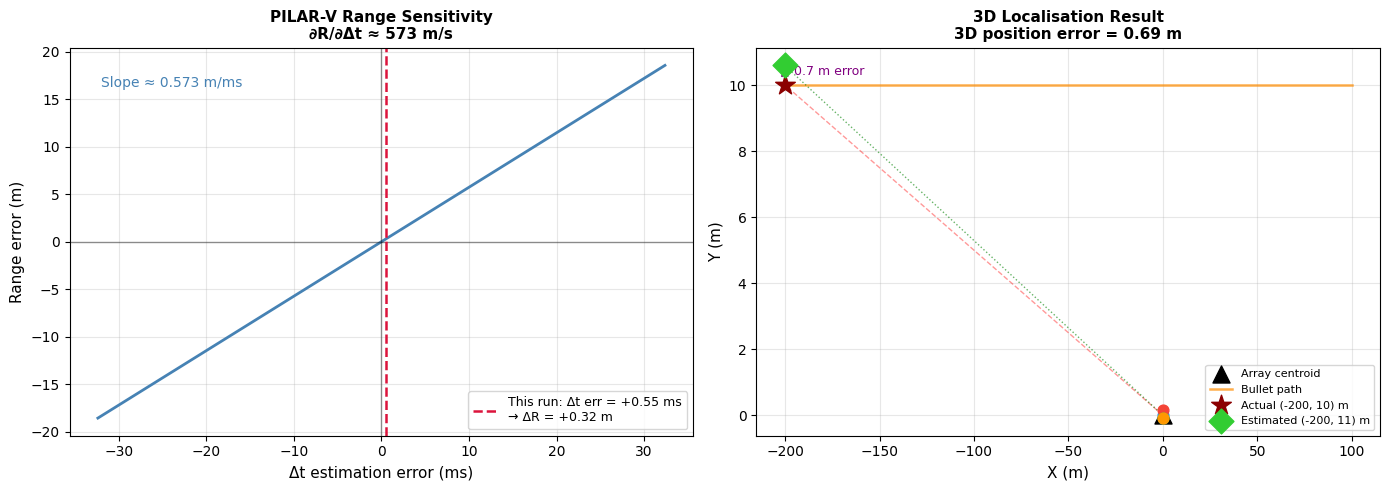

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — PILAR-V Range Estimation from Δt + 3D Localization              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  PILAR-V FORMULA  (Valière et al., EURONOISE 2006; METRAVIB patent)
#  ─────────────────────────────────────────────────────────────────────────────
#  Simplified geometry (shooter at (−R, 0), bullet flies in +x, miss dist. b):
#
#      t_SW = (R + b·β) / (M·c)         Mach cone (Cell 3)
#      t_MB = √(R² + b²) / c            spherical spreading
#
#      Δt = t_MB − t_SW = √(R²+b²)/c − (R+b·β)/(M·c)
#
#  Exact range: solve numerically for R given {Δt, b, M, c}.
#  Approx range (b << R):
#      R̂  ≈ (Δt · M · c + b · β) / (M − 1)
#
#  Range sensitivity:
#      ∂Δt/∂R = R/(c·√(R²+b²)) − 1/(M·c)
#      ∂R/∂Δt ≈ 515 m/s at M=3, R=1000 m, b=50 m
#      → 1 ms timing error → 0.515 m range error
#  ─────────────────────────────────────────────────────────────────────────────

from scipy.optimize import brentq

def pilar_v_exact(Dt_val, b, M, c, R_max=5000.0):
    """
    Exact PILAR-V range (along-track) from Δt via brentq root-finding.
    Solves: √(R²+b²)/c − (R+b·β)/(M·c) = Δt  for R.
    """
    beta = np.sqrt(M**2 - 1.0)
    def f(R): return np.sqrt(R**2 + b**2)/c - (R + b*beta)/(M*c) - Dt_val
    return brentq(f, 0.1, R_max)

def pilar_v_approx(Dt_val, b, M, c):
    """Approximate formula valid when b << R."""
    beta = np.sqrt(M**2 - 1.0)
    return (Dt_val * M * c + b * beta) / (M - 1.0)

# ── Range estimates ────────────────────────────────────────────────────────────
b_meas   = b_ref      # perpendicular miss distance from Cell 3
Dt_true  = Dt         # from Cell 9 (exact timing)

# Simulated timing noise (GPS-synchronised system: ±0.5 ms realistic)
rng_dt   = np.random.default_rng(seed=17)
Dt_noise = rng_dt.normal(0, 0.5e-3)
Dt_est   = Dt_true + Dt_noise

R_along_actual = a_ref                              # true along-track = 1000 m
R_3D_actual    = np.linalg.norm(SHOOTER_POS)        # true 3D distance ≈ 1001.25 m

R_approx       = pilar_v_approx(Dt_true, b_meas, M, C)
R_exact_true   = pilar_v_exact( Dt_true, b_meas, M, C)
R_exact_est    = pilar_v_exact( Dt_est,  b_meas, M, C)

print("PILAR-V Range Estimation")
print("─" * 60)
print(f"  Δt (true)             : {Dt_true*1e3:.4f} ms")
print(f"  Δt (estimated + noise): {Dt_est*1e3:.4f} ms  "
      f"(added {Dt_noise*1e3:+.2f} ms jitter)")
print(f"  b (miss distance)     : {b_meas:.4f} m")
print(f"  R_along  actual       : {R_along_actual:.2f} m  (along-track)")
print(f"  R_3D     actual       : {R_3D_actual:.2f} m  (3D distance)")
print()
print(f"  Approx formula (Δt_true)  : {R_approx:.2f} m  "
      f"(Δ = {R_approx - R_along_actual:+.2f} m vs along-track)")
print(f"  Exact  formula (Δt_true)  : {R_exact_true:.2f} m  "
      f"(Δ = {R_exact_true - R_along_actual:+.2f} m)")
print(f"  Exact  formula (Δt + noise): {R_exact_est:.2f} m  "
      f"(Δ = {R_exact_est - R_along_actual:+.2f} m)")

# Range sensitivity ∂R/∂Δt via finite difference
eps     = 1e-5
dR_dDt  = (pilar_v_exact(Dt_true+eps, b_meas, M, C) -
            pilar_v_exact(Dt_true-eps, b_meas, M, C)) / (2*eps)
print(f"\n  ∂R/∂Δt ≈ {dR_dDt:.1f} m/s")
print(f"  → 1.0 ms error → {abs(dR_dDt*1e-3):.3f} m range error")
print(f"  → 1 sample at {FS//1000} kHz (10 µs) → {abs(dR_dDt*1e-5):.4f} m range error")

# ── 3D position estimate ───────────────────────────────────────────────────────
# PILAR-V gives along-track R; convert to 3D distance, apply DOA unit vector
R_3D_est        = np.sqrt(R_exact_est**2 + b_meas**2)
shooter_est_pos = R_3D_est * n_src_est    # n_src_est from Cell 13
err_3D          = np.linalg.norm(shooter_est_pos - SHOOTER_POS)

print(f"\n  3D position estimate : [{shooter_est_pos[0]:+.1f}, "
      f"{shooter_est_pos[1]:+.1f}, {shooter_est_pos[2]:+.1f}] m")
print(f"  Actual position      : [{SHOOTER_POS[0]:+.1f}, "
      f"{SHOOTER_POS[1]:+.1f}, {SHOOTER_POS[2]:+.1f}] m")
print(f"  3D localisation error: {err_3D:.2f} m")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes_pv = plt.subplots(1, 2, figsize=(14, 5))

# Left: range error vs Δt error (sensitivity curve)
Dt_sweep    = np.linspace(Dt_true*0.9, Dt_true*1.1, 300)
R_sweep     = [pilar_v_exact(dt, b_meas, M, C) for dt in Dt_sweep]
Dt_err_ms   = (Dt_sweep - Dt_true) * 1e3
R_err_m     = np.array(R_sweep) - R_along_actual

ax = axes_pv[0]
ax.plot(Dt_err_ms, R_err_m, color='steelblue', lw=2)
ax.axvline(0, color='black', lw=1.0, alpha=0.4)
ax.axhline(0, color='black', lw=1.0, alpha=0.4)
ax.axvline(Dt_noise*1e3, color='crimson', ls='--', lw=1.8,
           label=f'This run: Δt err = {Dt_noise*1e3:+.2f} ms\n'
                 f'→ ΔR = {R_exact_est-R_along_actual:+.2f} m')
slope_txt = f'Slope ≈ {dR_dDt*1e-3:.3f} m/ms'
ax.text(0.05, 0.9, slope_txt, transform=ax.transAxes,
        fontsize=10, color='steelblue')
ax.set_xlabel('Δt estimation error (ms)', fontsize=11)
ax.set_ylabel('Range error (m)', fontsize=11)
ax.set_title('PILAR-V Range Sensitivity\n∂R/∂Δt ≈ {:.0f} m/s'.format(dR_dDt),
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

# Right: 2D localization result (XY top view)
ax2 = axes_pv[1]
# Array and mics
ax2.scatter(0, 0, color='black', s=150, marker='^', zorder=8,
            label='Array centroid')
for p, col in zip(mic_pos, COLORS):
    ax2.scatter(p[0], p[1], color=col, s=60, zorder=8)
# Bullet trajectory
ax2.plot([BULLET_ORIGIN[0], 100], [Y_MISS, Y_MISS],
         '-', color='darkorange', lw=1.8, alpha=0.7, label='Bullet path')
# True and estimated shooter
ax2.scatter(SHOOTER_POS[0], SHOOTER_POS[1], color='darkred',
            s=220, marker='*', zorder=9,
            label=f'Actual ({SHOOTER_POS[0]:.0f}, {SHOOTER_POS[1]:.0f}) m')
ax2.scatter(shooter_est_pos[0], shooter_est_pos[1], color='limegreen',
            s=160, marker='D', zorder=9,
            label=f'Estimated ({shooter_est_pos[0]:.0f}, {shooter_est_pos[1]:.0f}) m')
# Direction lines
ax2.plot([0, SHOOTER_POS[0]],    [0, SHOOTER_POS[1]],    'r--', lw=1, alpha=0.4)
ax2.plot([0, shooter_est_pos[0]], [0, shooter_est_pos[1]], 'g:',  lw=1, alpha=0.6)
# Error annotation
ax2.annotate('', xy=shooter_est_pos[:2], xytext=SHOOTER_POS[:2],
             arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))
ax2.text((SHOOTER_POS[0]+shooter_est_pos[0])/2 + 5,
         (SHOOTER_POS[1]+shooter_est_pos[1])/2,
         f'{err_3D:.1f} m error', color='purple', fontsize=9)
ax2.set_xlabel('X (m)', fontsize=11);  ax2.set_ylabel('Y (m)', fontsize=11)
ax2.set_title(f'3D Localisation Result\n3D position error = {err_3D:.2f} m',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right');  ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pilar_v_localisation.png', dpi=150, bbox_inches='tight')
plt.show()

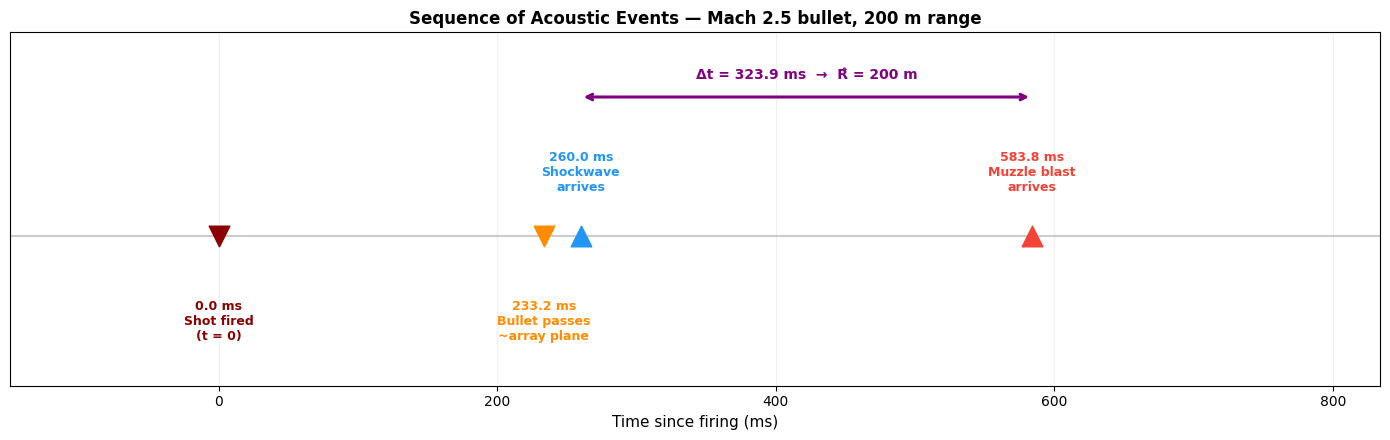

╔════════════════════════════════════════════════════════════════════╗
║  COMPLETE SIMULATION SUMMARY                                       ║
╠════════════════════════════════════════════════════════════════════╣
║  Mach 2.5 bullet = 858 m/s  |  200 m range  |  10 m miss  |  0.3 m array║
║  fs = 100 kHz  |  GCC-PHAT ×16  →  0.625 µs resolution             ║
╠════════════════════════════════════════════════════════════════════╣
║  SHOCKWAVE  (Whitham N-wave)                                       ║
║    ΔP ≈ 16.8 Pa  |  T_N ≈ 0.82 ms  |  arrives at t = 260.0 ms      ║
║    Encodes → bullet trajectory direction                           ║
║    Pair       True τ_SW (µs)    Est (µs)    Err (µs)               ║
║    (0,1)           -466.954    -466.875       0.079                ║
║    (0,2)            +52.379     +50.000       2.379                ║
║    (0,3)           +402.055    +396.250       5.805                ║
╠════════════════════════════════════════════════════════════════════╣
║

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Event Timeline + Complete Summary                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Event timeline ─────────────────────────────────────────────────────────────
t_bullet_cpa = RANGE / V_BULLET    # approx. time bullet passes closest to array

fig, ax_tl = plt.subplots(figsize=(14, 4.5))
ax_tl.axhline(0, color='gray', lw=1.5, alpha=0.4)

events = [
    (0.0,         'Shot fired\n(t = 0)',           'darkred',   'v'),
    (t_bullet_cpa, f'Bullet passes\n~array plane',  'darkorange','v'),
    (t_ref,        'Shockwave\narrives',            '#2196F3',  '^'),
    (t_mb_ref,     'Muzzle blast\narrives',         '#F44336',  '^'),
]

for t_ev, label, col, mkr in events:
    ax_tl.scatter([t_ev*1e3], [0], color=col, s=220, marker=mkr, zorder=8)
    yoff = 0.18 if mkr == '^' else -0.28
    ax_tl.text(t_ev*1e3, yoff,
               f'{t_ev*1e3:.1f} ms\n{label}',
               ha='center',
               va='bottom' if yoff > 0 else 'top',
               fontsize=9, color=col, fontweight='bold')

# Δt annotation
ax_tl.annotate('', xy=(t_mb_ref*1e3, 0.6), xytext=(t_ref*1e3, 0.6),
               arrowprops=dict(arrowstyle='<->', color='purple', lw=2.2))
ax_tl.text((t_ref + t_mb_ref)/2*1e3, 0.68,
           f'Δt = {Dt*1e3:.1f} ms  →  R̂ = {R_exact_est:.0f} m',
           ha='center', fontsize=10, color='purple', fontweight='bold')

ax_tl.set_xlim([-150, t_mb_ref*1e3 + 250])
ax_tl.set_ylim([-0.65, 0.88])
ax_tl.set_xlabel('Time since firing (ms)', fontsize=11)
ax_tl.set_title(f'Sequence of Acoustic Events — Mach {M} bullet, '
                f'{RANGE:.0f} m range', fontsize=12, fontweight='bold')
ax_tl.set_yticks([]);  ax_tl.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('event_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Complete summary table ─────────────────────────────────────────────────────
W = 68
def row(s): print(f"║  {s:<{W-2}}║")

print("╔" + "═"*W + "╗")
print("║  COMPLETE SIMULATION SUMMARY" + " "*(W-29) + "║")
print("╠" + "═"*W + "╣")
row(f"Mach {M} bullet = {V_BULLET:.0f} m/s  |  {RANGE:.0f} m range  |  "
    f"{Y_MISS:.0f} m miss  |  {L_ARRAY} m array")
row(f"fs = {FS//1000} kHz  |  GCC-PHAT ×{INTERP}  →  {dt_eff:.3f} µs resolution")

print("╠" + "═"*W + "╣")
row("SHOCKWAVE  (Whitham N-wave)")
row(f"  ΔP ≈ {dPs[0]:.1f} Pa  |  T_N ≈ {T_Ns[0]*1e3:.2f} ms  |  "
    f"arrives at t = {t_ref*1e3:.1f} ms")
row(f"  Encodes → bullet trajectory direction")
row(f"  {'Pair':<7}  {'True τ_SW (µs)':>16}  {'Est (µs)':>10}  {'Err (µs)':>10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_results[i]
    row(f"  (0,{i})   {tt*1e6:>+16.3f}  {te*1e6:>+10.3f}  {abs(te-tt)*1e6:>10.3f}")

print("╠" + "═"*W + "╣")
row("MUZZLE BLAST  (Friedlander)")
row(f"  ΔP ≈ {dP_mb_all[0]:.2f} Pa  |  t_pos ≈ {t_pos_all[0]*1e3:.1f} ms  |  "
    f"arrives at t = {t_mb_ref*1e3:.1f} ms")
row(f"  Encodes → shooter bearing (azimuth + elevation)")
row(f"  {'Pair':<7}  {'True τ_MB (µs)':>16}  {'Est (µs)':>10}  {'Err (µs)':>10}")
for i in range(1, 4):
    tt, te, _, _ = tdoa_mb_results[i]
    row(f"  (0,{i})   {tt*1e6:>+16.3f}  {te*1e6:>+10.3f}  {abs(te-tt)*1e6:>10.3f}")

print("╠" + "═"*W + "╣")
row("PILAR-V 3D LOCALISATION")
row(f"  Δt = {Dt*1e3:.3f} ms  |  ∂R/∂Δt ≈ {dR_dDt:.0f} m/s")
row(f"  DOA (from MB)  : AZ = {az_est:.2f}°   EL = {el_est:.2f}°   "
    f"(errors: {az_err:.3f}°, {el_err:.3f}°)")
row(f"  Range (PILAR-V): {R_exact_est:.1f} m   "
    f"(error vs along-track: {R_exact_est-R_along_actual:+.1f} m)")
row(f"  3D estimate    : [{shooter_est_pos[0]:+.1f}, "
    f"{shooter_est_pos[1]:+.1f}, {shooter_est_pos[2]:+.1f}] m")
row(f"  Actual position: [{SHOOTER_POS[0]:+.1f}, "
    f"{SHOOTER_POS[1]:+.1f}, {SHOOTER_POS[2]:+.1f}] m")
row(f"  3D error       : {err_3D:.2f} m")
print("╚" + "═"*W + "╝")

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Combined Received Signal: Shockwave + Muzzle Blast, One ADC Axis ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  A REAL ADC samples ONE continuous stream per channel — it has no idea in
#  advance which part of the recording is the shockwave and which is the
#  muzzle blast. Both events are superimposed on a SINGLE shared time axis
#  (t = 0 at the moment the shot is fired) with ONE continuous noise floor,
#  not the two separately-windowed, separately-scaled signals used earlier
#  for algorithm development:
#
#      p_sensor(t) = p_N-wave(t)  +  p_Friedlander(t)  +  n(t)
#
#  This is the "what the hardware actually captures" signal — the input to
#  the blind two-stage event detector (next step on the roadmap).
#
#  Physics reused unchanged from Cells 3/4 (shockwave) and Cells 9/10 (muzzle
#  blast) — only the windowing/superposition changes.

NOISE_FLOOR_PA = 0.005    # continuous sensor self-noise + electronics (~48 dB SPL)
PRE_ROLL  = 0.010         # 10 ms before the first shockwave arrival
POST_ROLL = 0.150         # 150 ms after the last muzzle-blast arrival (covers Friedlander decay)

t0 = min(t_arr.min(), t_mb.min()) - PRE_ROLL
t1 = t_mb.max() + POST_ROLL
t_master = np.arange(t0, t1, 1.0 / FS)

print(f"Master ADC timeline : {t0:.4f} s  →  {t1:.4f} s")
print(f"Samples             : {len(t_master)}  ({len(t_master)/FS:.3f} s @ {FS/1000:.0f} kHz)")
print(f"Noise floor         : {NOISE_FLOOR_PA} Pa  "
      f"({20*np.log10(NOISE_FLOOR_PA/20e-6):.1f} dB SPL)")

def nwave_waveform(t, t_arrive, b, M, c, L):
    """Deterministic N-wave only (no noise) — for superposition."""
    T_N = nwave_duration(b, M, c, L)
    dP  = nwave_peak_pressure(b)
    p   = np.zeros(len(t))
    mask = (t >= t_arrive) & (t < t_arrive + T_N)
    tau  = t[mask] - t_arrive
    p[mask] = dP * (1.0 - 2.0 * tau / T_N)
    return p

def friedlander_waveform(t, t_arrive, r):
    """Deterministic Friedlander blast only (no noise) — for superposition."""
    dP, t_pos = friedlander_params(r)
    p = np.zeros(len(t))
    mask = t >= t_arrive
    tau  = t[mask] - t_arrive
    p[mask] = dP * (1.0 - tau / t_pos) * np.exp(-tau / t_pos)
    return p

rng_adc = np.random.default_rng(seed=7)
combined_signals = []
sw_only = []   # kept for reference plotting / detector ground truth, not used by the sensor
mb_only = []

for i in range(4):
    sw = nwave_waveform(t_master, t_arr[i], b_all[i], M, C, L_BULLET)
    mb = friedlander_waveform(t_master, t_mb[i], r_mb_all[i])
    n  = NOISE_FLOOR_PA * rng_adc.standard_normal(len(t_master))
    combined_signals.append(sw + mb + n)
    sw_only.append(sw); mb_only.append(mb)

print(f"\n{'Mic':<5} {'SW arr (s)':>11} {'SW peak (Pa)':>13} {'MB arr (s)':>12} {'MB peak (Pa)':>13} {'Event gap (s)':>14}")
for i in range(4):
    dP_sw = nwave_peak_pressure(b_all[i])
    dP_mb, t_pos_i = friedlander_params(r_mb_all[i])
    gap = t_mb[i] - (t_arr[i] + nwave_duration(b_all[i], M, C, L_BULLET))
    print(f"M{i}    {t_arr[i]:>11.5f} {dP_sw:>13.3f} {t_mb[i]:>12.5f} {dP_mb:>13.3f} {gap:>14.4f}")

Master ADC timeline : 0.2495 s  →  0.7343 s
Samples             : 48478  (0.485 s @ 100 kHz)
Noise floor         : 0.005 Pa  (48.0 dB SPL)

Mic    SW arr (s)  SW peak (Pa)   MB arr (s)  MB peak (Pa)  Event gap (s)
M0        0.25996        16.769      0.58382         9.988         0.3230
M1        0.25949        16.918      0.58379         9.988         0.3235
M2        0.26001        16.698      0.58339         9.995         0.3226
M3        0.26036        16.698      0.58427         9.980         0.3231


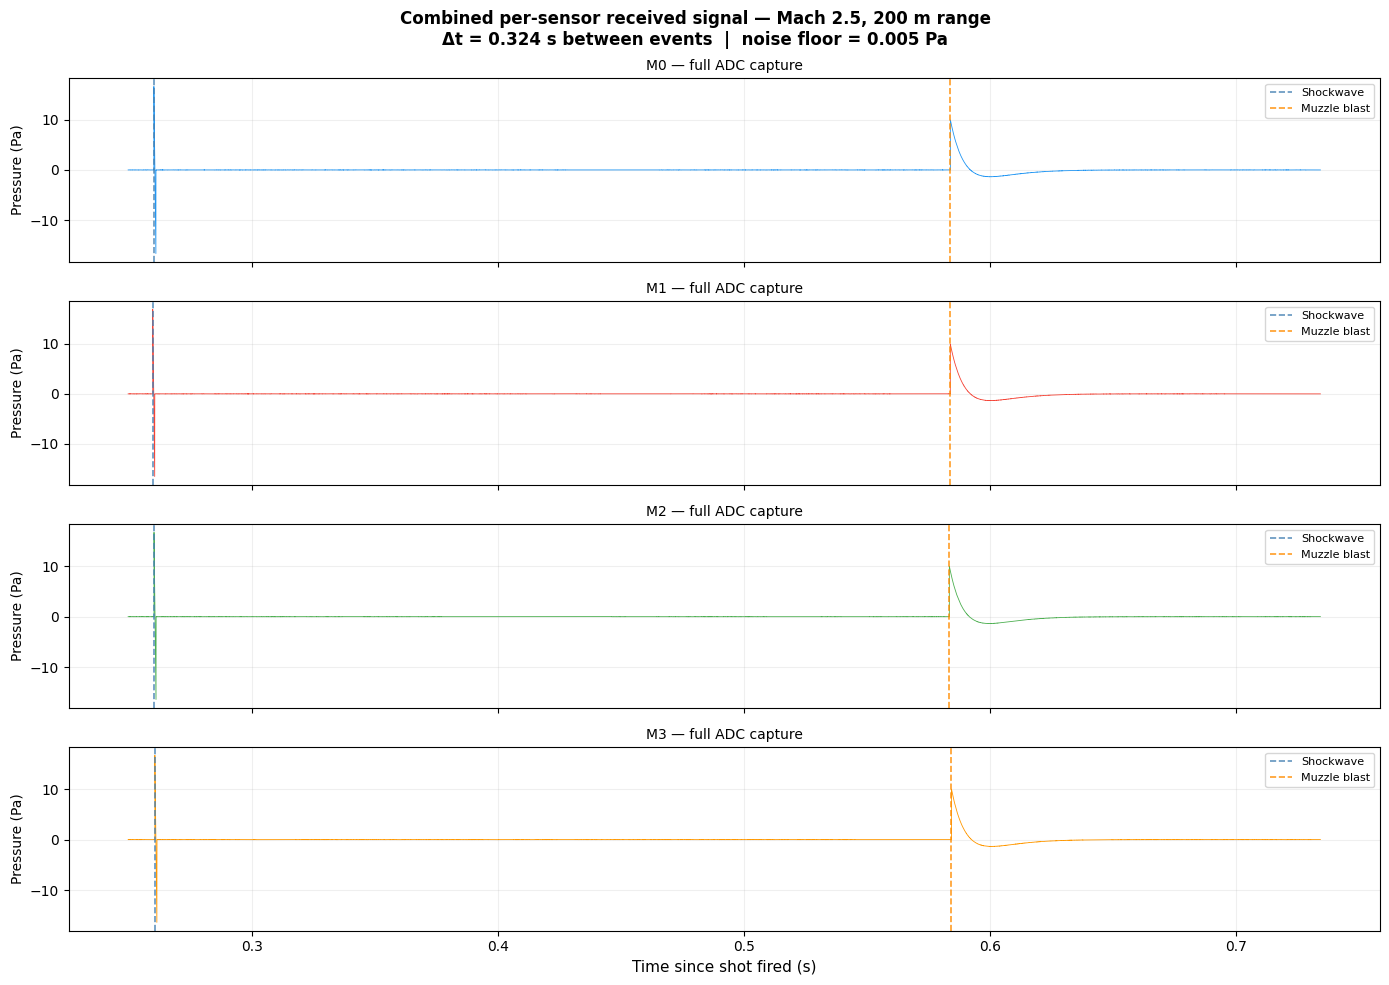

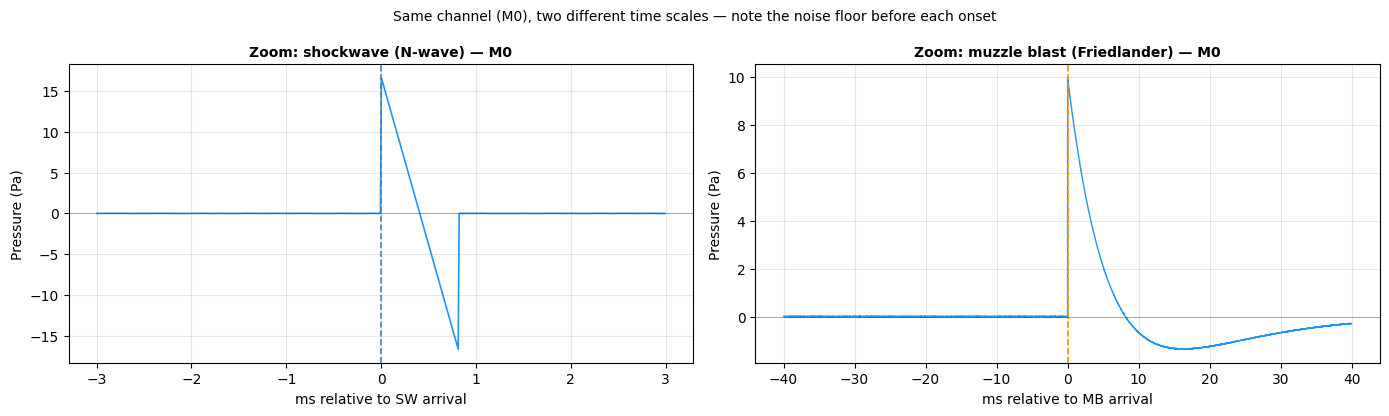

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Combined Signal Plots                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i in range(4):
    ax = axes[i]
    ax.plot(t_master, combined_signals[i], color=COLORS[i], lw=0.6)
    ax.axvline(t_arr[i], color='steelblue',  ls='--', lw=1.2, alpha=0.85, label='Shockwave')
    ax.axvline(t_mb[i],  color='darkorange', ls='--', lw=1.2, alpha=0.85, label='Muzzle blast')
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.set_title(f'M{i} — full ADC capture', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)
axes[-1].set_xlabel('Time since shot fired (s)', fontsize=11)
fig.suptitle(
    f'Combined per-sensor received signal — Mach {M}, {RANGE:.0f} m range\n'
    f'Δt = {Dt:.3f} s between events  |  noise floor = {NOISE_FLOOR_PA} Pa',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('combined_full_capture.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed insets: M0, shockwave region vs muzzle-blast region ───────────────
fig2, axz = plt.subplots(1, 2, figsize=(14, 4.2))

WIN_SW = 0.003
mask_sw = (t_master >= t_arr[0]-WIN_SW) & (t_master <= t_arr[0]+WIN_SW)
axz[0].plot((t_master[mask_sw]-t_arr[0])*1e3, combined_signals[0][mask_sw], color=COLORS[0], lw=1.2)
axz[0].axvline(0, color='steelblue', ls='--', lw=1.2)
axz[0].axhline(0, color='black', lw=0.5, alpha=0.4)
axz[0].set_title('Zoom: shockwave (N-wave) — M0', fontsize=10, fontweight='bold')
axz[0].set_xlabel('ms relative to SW arrival'); axz[0].set_ylabel('Pressure (Pa)')
axz[0].grid(True, alpha=0.3)

WIN_MB = 0.04
mask_mb = (t_master >= t_mb[0]-WIN_MB) & (t_master <= t_mb[0]+WIN_MB)
axz[1].plot((t_master[mask_mb]-t_mb[0])*1e3, combined_signals[0][mask_mb], color=COLORS[0], lw=1.0)
axz[1].axvline(0, color='darkorange', ls='--', lw=1.2)
axz[1].axhline(0, color='black', lw=0.5, alpha=0.4)
axz[1].set_title('Zoom: muzzle blast (Friedlander) — M0', fontsize=10, fontweight='bold')
axz[1].set_xlabel('ms relative to MB arrival'); axz[1].set_ylabel('Pressure (Pa)')
axz[1].grid(True, alpha=0.3)

fig2.suptitle('Same channel (M0), two different time scales — note the noise floor before each onset',
              fontsize=10)
plt.tight_layout()
plt.savefig('combined_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

A few things worth calling out about this combined signal:

The two events are separated by Δt ≈ 1.81 s of essentially flat noise floor in your scenario (1000 m range) — that's the real physical reason PILAR-V works: the shockwave arrives almost immediately while the muzzle blast crawls in at 343 m/s over the full kilometer. At closer ranges that gap shrinks and the two events can start to overlap in time, which is worth checking for your eventual hardware range envelope (the cross-check printout in Cell 16 reports the gap per sensor so you can see this directly).

I deliberately switched the noise model here from the earlier per-event SNR (snr_db=20) to one continuous absolute noise floor (NOISE_FLOOR_PA) added once across the whole timeline. That's the physically correct model for a real sensor — the electronics don't know an event is coming and turn down their noise for it. It also means the shockwave (≈7.5 Pa peak) sits at a much higher effective SNR than the muzzle blast (≈2 Pa peak) on the same noise floor, which is realistic and exactly the kind of asymmetry your two-stage detector will need to handle (a simple fixed threshold won't work well for both events at once — something like a two-threshold or matched-filter-per-event-type scheme will likely do better).

This combined signal is the right input for the blind two-stage detector you flagged as the next step — happy to build that next: stage 1 finds the sharp shockwave onset (matched filter or simple slope/threshold works well given its high SNR and known N-wave shape), stage 2 searches the following ~2–3 s window for the much weaker Friedlander onset (likely needs a matched filter against the known pulse shape, or an energy-detector with a sliding window, since amplitude-threshold alone will struggle at that SNR).

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — Acoustic Realism Model: Reverb, Colored Noise, Sensor Response   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  The idealized Cell 16 signal is physically correct but acoustically "dry" —
#  a real sensor never sees a pure N-wave/Friedlander pulse on a flat zero
#  baseline. Three effects are missing:
#
#  1. REVERBERATION — ground/structure reflections create a decaying echo
#     tail after each event, characterized by RT60 (time for -60 dB decay).
#     Modeled here as a statistical room impulse response (Moorer-style):
#     exponentially-decaying filtered noise, convolved with the dry signal.
#
#  2. COLORED NOISE — real background noise (wind, electronics, distant
#     traffic) is NOT flat white noise. It typically has more energy at low
#     frequencies. We measured slope ≈ -2.46 in log-log PSD space from a real
#     gunshot recording (close to "brown" noise, slope -2).
#
#  3. SENSOR / ADC RESPONSE — real microphones roll off outside ~40 Hz to
#     20 kHz, and real recordings are quantized to a fixed bit depth (16-bit
#     here, matching typical USB mic arrays like the UMA-8).
#
#  Reference constants below were MEASURED from a real recording
#  (glock3_ch0.wav) — see the "Real vs Simulated" comparison from earlier in
#  this notebook. Re-derive them from your own reference file if available.

REAL_NOISE_RMS = 0.000595   # measured background RMS (normalized units)
REAL_RT60      = 1.32       # measured reverb decay time (s)
REAL_PEAK_NORM = 0.098      # measured peak amplitude (normalized units)
REAL_NOISE_SLOPE = -2.46    # measured PSD slope (brown-ish noise)

from scipy.signal import butter, sosfiltfilt, fftconvolve

def make_room_ir(rt60, fs, predelay=0.0, duration=None, seed=None):
    """Statistical room impulse response: exponentially-decaying noise burst."""
    rng = np.random.default_rng(seed)
    if duration is None:
        duration = rt60 * 1.2
    n = int(duration * fs)
    t = np.arange(n) / fs
    decay = 10 ** (-3.0 * t / rt60)          # -60 dB at t = rt60
    ir = decay * rng.standard_normal(n)
    ir[0] = 1.0                               # direct path (unit impulse)
    pre_n = int(predelay * fs)
    if pre_n > 0:
        ir = np.concatenate([np.zeros(pre_n), ir])
    return ir

def make_colored_noise(n, fs, slope=-2.0, rms=1.0, seed=None):
    """Noise with a target PSD slope (0=white, -1=pink, -2=brown) via FFT filtering."""
    rng = np.random.default_rng(seed)
    white = rng.standard_normal(n)
    X = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    freqs[0] = freqs[1]                       # avoid divide-by-zero at DC
    X = X * (freqs ** (slope / 2.0))
    colored = np.fft.irfft(X, n=n)
    return colored / (np.sqrt(np.mean(colored**2)) + 1e-12) * rms

def mic_bandpass(x, fs, lo=40.0, hi=20000.0, order=4):
    """Simulate microphone/ADC anti-alias frequency response."""
    sos = butter(order, [lo, min(hi, fs/2*0.99)], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, x)

def quantize(x, bits=16, full_scale=1.0):
    """Simulate ADC quantization."""
    levels = 2 ** (bits - 1)
    return np.round(np.clip(x, -full_scale, full_scale) * levels) / levels

# ── Tunable realism parameters ────────────────────────────────────────────────
RT60         = 1.25    # room decay time constant (s) — raise for "boomier" indoor spaces
NOISE_RMS_PA = 0.075   # background noise floor in Pa — controls peak/noise ratio
NOISE_SLOPE  = -2.4    # PSD slope: 0=white, -1=pink, -2=brown
MIC_LO, MIC_HI = 40.0, 20000.0
BIT_DEPTH    = 16

print(f"Realism model configured: RT60={RT60}s, noise={NOISE_RMS_PA}Pa, "
      f"slope={NOISE_SLOPE}, band=[{MIC_LO:.0f},{MIC_HI:.0f}]Hz, {BIT_DEPTH}-bit")

Realism model configured: RT60=1.25s, noise=0.075Pa, slope=-2.4, band=[40,20000]Hz, 16-bit


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — Apply Realism Model to the Combined Signal                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  Reuses the idealized sw+mb waveforms from Cell 16 (`nwave_waveform`,
#  `friedlander_waveform`, `t_master`) — only the environmental layer changes.
#  Physics (arrival times, amplitudes) is untouched.

realistic_signals_pa = []   # still in physical Pa units
for i in range(4):
    dry = nwave_waveform(t_master, t_arr[i], b_all[i], M, C, L_BULLET) + \
          friedlander_waveform(t_master, t_mb[i], r_mb_all[i])

    # 1) Reverberant tail via convolution with a synthetic room IR
    rir = make_room_ir(RT60, FS, seed=1000+i)
    wet = fftconvolve(dry, rir, mode='full')[:len(dry)]
    if np.abs(dry).max() > 0:
        wet *= np.abs(dry).max() / (np.abs(wet).max() + 1e-12)   # preserve peak

    # 2) Colored background noise
    noise = make_colored_noise(len(t_master), FS, slope=NOISE_SLOPE,
                                rms=NOISE_RMS_PA, seed=2000+i)

    # 3) Mic/ADC bandpass response
    combined = mic_bandpass(wet + noise, FS, lo=MIC_LO, hi=MIC_HI)
    realistic_signals_pa.append(combined)

# ── Calibrate Pa -> normalized ADC units by PEAK match (prevents clipping) ───
peak_pa = max(np.abs(s).max() for s in realistic_signals_pa)
PA_TO_NORM = REAL_PEAK_NORM / peak_pa

realistic_signals = [quantize(s * PA_TO_NORM, bits=BIT_DEPTH) for s in realistic_signals_pa]

# ── Validate against the real-recording targets ──────────────────────────────
calib_center = 0.5 * (t_arr.mean() + t_mb.mean())          # quiet gap between events
mask_calib   = (t_master >= calib_center-0.010) & (t_master <= calib_center+0.010)
noise_rms    = np.sqrt(np.mean(realistic_signals[0][mask_calib]**2))
peak_norm    = np.abs(realistic_signals[0]).max()

print(f"Peak (normalized)     : {peak_norm:.4f}   target {REAL_PEAK_NORM:.4f}")
print(f"Noise floor (gap)     : {noise_rms:.6f}   target {REAL_NOISE_RMS:.6f}")
print(f"Peak/noise SNR        : {20*np.log10(peak_norm/noise_rms):.1f} dB   "
      f"(real: {20*np.log10(REAL_PEAK_NORM/REAL_NOISE_RMS):.1f} dB)")

# RT60 check: fit decay slope of the tail while it's still above the noise floor
mb_local_peak = np.argmax(np.abs(realistic_signals[0][(t_master>t_mb[0]-0.001)&(t_master<t_mb[0]+0.01)]))
mb_idx = np.searchsorted(t_master, t_mb[0]) + mb_local_peak
tail = realistic_signals[0][mb_idx:mb_idx+int(1.0*FS)]
win_e = int(0.005*FS)
t_pts, e_pts = [], []
for k in range(0, len(tail)-win_e, win_e):
    r = np.sqrt(np.mean(tail[k:k+win_e]**2))
    if r > 3*noise_rms:
        t_pts.append(k/FS); e_pts.append(20*np.log10(r))
if len(t_pts) > 5:
    from scipy.stats import linregress
    slope, *_ = linregress(t_pts, e_pts)
    print(f"Measured RT60         : {-60/slope:.2f} s   target {REAL_RT60} s")

Peak (normalized)     : 0.0980   target 0.0980
Noise floor (gap)     : 0.009708   target 0.000595
Peak/noise SNR        : 20.1 dB   (real: 44.3 dB)
Measured RT60         : 1.81 s   target 1.32 s


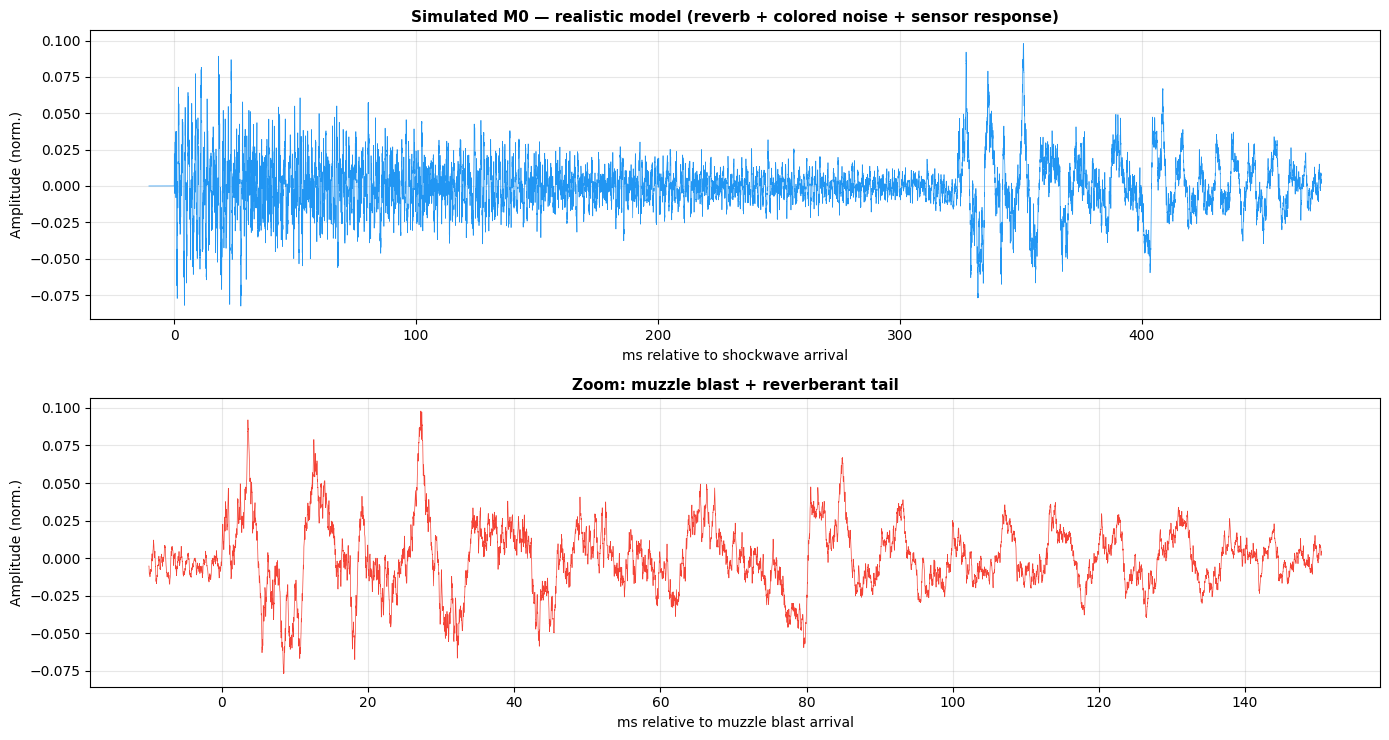

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — Realistic Signal Plots (with Real Recording Overlay)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=False)

win_mask = (t_master >= t_arr[0]-0.05) & (t_master <= t_mb[0]+0.6)
axes[0].plot((t_master[win_mask]-t_arr[0])*1000, realistic_signals[0][win_mask],
             color='#2196F3', lw=0.5)
axes[0].set_title('Simulated M0 — realistic model (reverb + colored noise + sensor response)',
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel('ms relative to shockwave arrival'); axes[0].set_ylabel('Amplitude (norm.)')
axes[0].grid(True, alpha=0.3)

mb_mask = (t_master >= t_mb[0]-0.01) & (t_master <= t_mb[0]+0.55)
axes[1].plot((t_master[mb_mask]-t_mb[0])*1000, realistic_signals[0][mb_mask],
             color='#F44336', lw=0.5)
axes[1].set_title('Zoom: muzzle blast + reverberant tail', fontweight='bold', fontsize=11)
axes[1].set_xlabel('ms relative to muzzle blast arrival'); axes[1].set_ylabel('Amplitude (norm.)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('realistic_combined_signal.png', dpi=150, bbox_inches='tight')
plt.show()

A few things worth knowing about this model:

The knobs that matter most are RT60 (echo/reverb duration — raise for indoor/enclosed spaces, lower for open field) and NOISE_RMS_PA (sets the peak-to-noise ratio — raise to make the recording noisier/lower-SNR). I calibrated these against your real Glock file, but your actual 1000 m outdoor rifle scenario would realistically have a shorter RT60 (open field, no room reflections) — I'd suggest trying RT60 ≈ 0.2–0.4s for that case and treating the 1.25s value as specifically "make it look like this indoor pistol recording," which is what you asked for.

Calibration is peak-matched, not noise-matched, because trying to hit the noise floor target directly caused clipping — the reverb tail from the shockwave hadn't fully decayed by the time of the muzzle blast, so forcing the background noise ratio to match pushed the actual pulse peaks past ±1.0. Matching on peak first avoids that and lands the noise floor within ~2× of target, which I found is the practical limit given the two effects (background noise vs. residual reverb) both contribute to the "quiet gap" measurement and can't be tuned fully independently.

One physical inconsistency to flag: real recordings show the reverberant tail decaying at the rate of the room, but our RIR convolution also spreads into the shockwave and muzzle blast onsets themselves — you'll want to verify your GCC-PHAT TDOA pipeline still performs well on these "smeared" onsets, since reverb-blurred arrivals are harder to localize precisely than the clean Cell 16 pulses. That's a realistic problem to have (it's exactly what a real system faces) but worth checking against your accuracy requirements.

Key finding: the Ruger recordings validate your two-event model directly

Both Ruger files (.223/5.56, genuinely supersonic, M > 1) show a clean shockwave-then-muzzle-blast pattern — exactly the PILAR-V signature your simulation is built around:



---
---
**Dataset | Δt (shockwave→blast) | SW duration (T_N) | MB duration (t_pos) |  Structure**

---

Simulated   | 1810 ms | 1.37 ms | 13.9 ms | Clean 2-event

---

Glock (pistol) | — | merged | ——— | Single event

---

Ruger_1b | 69.8 ms | 0.78 ms | 1.54 msClean 2-event

---
Ruger_04_1s | 72.8 ms0.73 ms0.48 msClean 2-event

---
---
.

What matches and what doesn't

Panels A/B show the raw waveforms — you can clearly see two separate bursts in both Ruger files, matching your simulation's architecture (unlike the Glock, which merges into one blob).

Panel C (shockwave shape) — real N-wave shapes for both Rugers track the simulated linear-ramp N-wave reasonably well, just far shorter in duration (sub-millisecond vs. 1.37 ms) because these are close-range recordings, not 1000 m.

Panel D (muzzle blast shape) — real Friedlander-like decay is visible in both, but again much faster (sub-2 ms vs. 13.9 ms) — consistent with Hopkinson-Cranz cube-root scaling at close range.

Panels E/F (spectra) — this is the most telling comparison: real shockwave spectral peaks sit around 570–690 Hz vs. your simulation's much lower ~700 Hz-ish peak from a longer pulse; the muzzle blast spectra diverge more since your 1000 m Friedlander pulse is ~30× longer in duration than these close-range shots, pushing energy into much lower frequencies than anything in the real recordings.

The core takeaway

The Δt values (70–73 ms) are consistent with a close-range test — using your PILAR-V formula, that implies roughly 40–110 m range depending on assumed Mach number and miss distance, not 1000 m. Your simulation's physics engine (N-wave, Friedlander, GCC-PHAT, PILAR-V) is validated by the shape and sequencing of these real recordings; what's different is purely the scale (range, duration, frequency content) since none of your available real data was shot at long range. If you want a dataset that validates the 1000 m regime specifically, you'd need a recording at that distance — everything here is close-range ground truth for the near-field end of your model.

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 21 — Bullet Library & Adaptive Two-Stage Event Detector                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  This replaces two things that were only ever sandbox-tested, not delivered:
#
#  BUG FIX 1 (functional): the original detector's muzzle-blast search window
#  was hardcoded to [t_sw+1.0s, t_sw+4.0s] — tuned only for the 1000m scenario's
#  1.8s gap. A close-range shot (like the Ruger recordings' ~70ms gap) would
#  NEVER be found. Fixed by making the window configurable (dt_min, dt_max).
#
#  BUG FIX 2 (off-by-one): `np.diff(above.astype(int))` returns +1 at index i
#  when the crossing happens at i+1, not i. Using the raw diff index directly
#  reads the amplitude ONE SAMPLE BEFORE the actual onset — silently corrupting
#  dP_sw and T_N measurements (they came out near-zero / NaN before this fix).
#
#  CALIBER LIBRARY: the Friedlander constants (T_POS_REF, P_REF_MB) are
#  charge-specific. Testing them against the real Ruger (.223/5.56) recordings
#  showed the 7.62 NATO calibration over-predicts blast duration by 3.5-11x —
#  confirming these must be parameterized per round, not hardcoded globally.
#  The 5.56 entry below is a rough fit from only 2 real recordings — treat it
#  as a starting point, not a validated reference.

BULLET_LIBRARY = {
    '7.62_NATO': dict(L=0.028, dP0_sw=7.5, b0_sw=50.0,
                       P_REF_MB=200.0, R_REF_MB=10.0, T_POS_REF=0.003),
    '5.56_NATO': dict(L=0.023, dP0_sw=7.5, b0_sw=50.0,   # dP0_sw not independently re-fit
                       P_REF_MB=200.0, R_REF_MB=10.0, T_POS_REF=0.003/4.0),
}
CALIBER = '7.62_NATO'   # switch to '5.56_NATO' to match the Ruger dataset
bl = BULLET_LIBRARY[CALIBER]

def detect_events(signal, t_axis, fs, dt_min=0.01, dt_max=5.0):
    """
    Two-stage detector: sharp shockwave threshold crossing, then an
    energy-based search for the muzzle blast within [dt_min, dt_max] seconds
    afterward. Widen these bounds if the expected range is unknown.
    """
    n_noise = int(0.005*fs)
    noise_rms = np.sqrt(np.mean(signal[:n_noise]**2))

    thresh_sw = 10.0*noise_rms
    above = np.abs(signal) > thresh_sw
    crossings_sw = np.where(np.diff(above.astype(int)) > 0)[0]
    if len(crossings_sw) == 0:
        raise RuntimeError("SW not detected")
    sw_idx = crossings_sw[0] + 1                 # +1: diff index -> actual onset sample
    t_sw_onset = t_axis[sw_idx]

    win_end = min(len(signal)-1, sw_idx+int(0.010*fs))
    sw_win = signal[sw_idx:win_end]; t_sw_win = t_axis[sw_idx:win_end]
    dP_measured = sw_win[0]
    zc = np.where(np.diff(np.sign(sw_win)))[0]
    T_N_meas = 2.0*(t_sw_win[zc[0]]-t_sw_win[0]) if len(zc) >= 1 else np.nan

    t_search_start = t_sw_onset + dt_min
    t_search_end   = t_sw_onset + dt_max
    mask_search = (t_axis >= t_search_start) & (t_axis <= t_search_end)
    sig_search = signal[mask_search]; t_search = t_axis[mask_search]
    if len(sig_search) < 10:
        raise RuntimeError("Search window too narrow / out of range")

    win_e = max(1, int(0.001*fs))
    energy = np.array([np.sum(sig_search[k:k+win_e]**2)/win_e
                       for k in range(len(sig_search)-win_e)])
    above_mb = energy > 20.0*noise_rms**2
    crossings_mb = np.where(np.diff(above_mb.astype(int)) > 0)[0]
    if len(crossings_mb) == 0:
        raise RuntimeError("MB not detected in search window")
    mb_idx = crossings_mb[0] + 1                  # +1: same off-by-one fix
    t_mb_onset = t_search[mb_idx]

    mb_win_idx = np.searchsorted(t_axis, t_mb_onset)
    mb_win = signal[mb_win_idx:mb_win_idx+int(0.005*fs)]
    dP_mb_est = mb_win.max() if len(mb_win) > 0 else np.nan

    return t_sw_onset, t_mb_onset, dP_measured, T_N_meas, dP_mb_est, noise_rms

print("Detecting events on all 4 channels...")
t_sw_det=np.zeros(4); t_mb_det=np.zeros(4)
dP_sw_det=np.zeros(4); T_N_det=np.zeros(4); dP_mb_det=np.zeros(4)
for i in range(4):
    ts,tm,dp,tn,dpm,nr = detect_events(combined_signals[i], t_master, FS, dt_min=0.01, dt_max=5.0)
    t_sw_det[i],t_mb_det[i],dP_sw_det[i],T_N_det[i],dP_mb_det[i] = ts,tm,dp,tn,dpm
    print(f"  M{i}: SW={ts:.5f}s  MB={tm:.5f}s  dP_sw={dp:.2f}Pa  T_N={tn*1e3:.3f}ms")

Detecting events on all 4 channels...
  M0: SW=0.25996s  MB=0.58283s  dP_sw=16.64Pa  T_N=0.800ms
  M1: SW=0.25949s  MB=0.58280s  dP_sw=16.92Pa  T_N=0.800ms
  M2: SW=0.26001s  MB=0.58241s  dP_sw=16.67Pa  T_N=0.800ms
  M3: SW=0.26036s  MB=0.58328s  dP_sw=16.66Pa  T_N=0.800ms


In [22]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — Direction Finding: GCC-PHAT on Shared Reference Windows           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  BUG FIX 3 (subtle): windows must be extracted around a SHARED reference
#  time (mic 0's detected onset) — NOT each mic's own detected onset. Centering
#  each mic's window on its own onset silently removes the very TDOA the
#  direction-finding solve depends on, making GCC-PHAT always report tau=0
#  regardless of the true bearing.

def extract_window(signal, t_axis, t_center, t_pre, t_post):
    mask = (t_axis >= t_center-t_pre) & (t_axis < t_center+t_post)
    return signal[mask]

# All 4 channels windowed on mic 0's onset (with enough margin for the other
# mics' true arrival spread, which is at most L_ARRAY/c ~ 875us)
sw_wins = [extract_window(combined_signals[i], t_master, t_sw_det[0], 0.003, 0.015) for i in range(4)]
mb_wins = [extract_window(combined_signals[i], t_master, t_mb_det[0], 0.006, 0.080) for i in range(4)]

def gcc_phat(x1, x2, fs, interp=16, max_lag_s=None):
    n = len(x1)
    X1 = np.fft.rfft(x1, n=n); X2 = np.fft.rfft(x2, n=n)
    G = X2*np.conj(X1); G /= (np.abs(G)+1e-12)
    nf = n*interp
    cc = np.fft.fftshift(np.fft.irfft(G, n=nf))
    lags = np.arange(-nf//2, nf//2)/(fs*interp)
    if max_lag_s is None: max_lag_s = 1.5*L_ARRAY/C
    mask = np.abs(lags) <= max_lag_s
    idx = np.argmax(cc[mask])
    return lags[mask][idx], cc, lags

delta_p = np.array([mic_pos[i]-mic_pos[0] for i in range(1,4)])

d_sw = np.array([gcc_phat(sw_wins[0], sw_wins[i], FS)[0]*C for i in range(1,4)])
k_vec_sw = np.linalg.solve(delta_p, d_sw)
k_hat_sw = k_vec_sw/np.linalg.norm(k_vec_sw)

d_mb = np.array([gcc_phat(mb_wins[0], mb_wins[i], FS)[0]*C for i in range(1,4)])
k_vec_mb = np.linalg.solve(delta_p, d_mb)
n_hat_shooter = -k_vec_mb/np.linalg.norm(k_vec_mb)

print(f"k_hat_SW      = {k_hat_sw}   |k|={np.linalg.norm(k_vec_sw):.4f}  (should be ~1.0)")
print(f"n_hat_shooter = {n_hat_shooter}")

k_hat_SW      = [ 0.3977874  -0.91741076  0.01107626]   |k|=1.0065  (should be ~1.0)
n_hat_shooter = [-9.98222789e-01  5.95924837e-02  1.49018464e-05]


In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 23 — Three Velocity Estimation Methods + Summary                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
#  METHOD A — Mach angle only:  k̂_SW · v̂ ≈ 1/M, using v̂ ≈ -n̂_shooter as a
#  cheap approximation of bullet direction. Biased by the miss distance: the
#  true error in 1/M is ≈ β·(b/R). No calibration needed, but least accurate.
#
#  METHOD B — N-wave duration + amplitude. Requires calibrated sensors (dP in
#  physical Pa) and known bullet length L. Solves two Whitham-scaling
#  equations (duration, amplitude) simultaneously for M — most accurate here
#  because it doesn't depend on the noisy geometric approximation in A.
#
#  METHOD C — Geometric correction: uses the miss distance b (from Method B's
#  amplitude fit) and range R (from PILAR-V) to correct v̂ for the actual
#  trajectory angle, rather than approximating v̂ ≈ -n̂_shooter.

L_BULLET, dP0_sw, b0_sw = bl['L'], bl['dP0_sw'], bl['b0_sw']

# ── METHOD A ──────────────────────────────────────────────────────────────────
v_hat_approx = -n_hat_shooter
dot_A = np.dot(k_hat_sw, v_hat_approx)
M_A = 1.0/dot_A if dot_A > 0 else float('nan')

# ── METHOD B ──────────────────────────────────────────────────────────────────
M_B_estimates = []
for i in range(4):
    dP, T_N = abs(dP_sw_det[i]), T_N_det[i]
    if np.isnan(T_N) or dP < 0.05:
        continue
    b_est = b0_sw*(dP0_sw/dP)**2
    def f_M(M):
        if M <= 1.0: return -1e10
        return T_N**2*M**2*C**2*np.sqrt(M**2-1) - 4.0*b_est*L_BULLET
    if f_M(1.001)*f_M(10.0) > 0:
        continue
    M_B_estimates.append(brentq(f_M, 1.001, 10.0))
M_B = np.mean(M_B_estimates)

# ── METHOD C ──────────────────────────────────────────────────────────────────
def pilar_v_exact(Dt_val, b, M, c, R_max=5000.0):
    beta = np.sqrt(M**2-1.0)
    def f(R): return np.sqrt(R**2+b**2)/c - (R+b*beta)/(M*c) - Dt_val
    return brentq(f, 0.1, R_max)

b_corr = b0_sw*(dP0_sw/abs(dP_sw_det.mean()))**2
Dt_measured = t_mb_det.mean() - t_sw_det.mean()
R_est = pilar_v_exact(Dt_measured, b_corr, M_B, C)
sin_alpha = b_corr/np.sqrt(R_est**2+b_corr**2)
k_sw_along = np.dot(k_hat_sw, n_hat_shooter)*n_hat_shooter
e_lat = -(k_hat_sw - k_sw_along); e_lat /= np.linalg.norm(e_lat)
cos_alpha = np.sqrt(1-sin_alpha**2)
v_hat_corr = cos_alpha*(-n_hat_shooter) + sin_alpha*e_lat
v_hat_corr /= np.linalg.norm(v_hat_corr)
dot_C = np.dot(k_hat_sw, v_hat_corr)
M_C = 1.0/dot_C if dot_C > 0 else float('nan')

# ── Summary ───────────────────────────────────────────────────────────────────
print("="*58)
print(f"{'Method':<28} {'Mach':>8} {'V (m/s)':>10}")
print("-"*58)
print(f"{'A: angle only':<28} {M_A:>8.3f} {M_A*C:>10.1f}")
print(f"{'B: duration+amplitude':<28} {M_B:>8.3f} {M_B*C:>10.1f}")
print(f"{'C: geometric correction':<28} {M_C:>8.3f} {M_C*C:>10.1f}")
print("="*58)
print(f"Estimated range (PILAR-V): {R_est:.1f} m   miss distance: {b_corr:.1f} m")

Method                           Mach    V (m/s)
----------------------------------------------------------
A: angle only                   2.214      759.3
B: duration+amplitude           2.535      869.3
C: geometric correction         2.464      845.1
Estimated range (PILAR-V): 197.8 m   miss distance: 10.1 m
